# **Project setup (Google Colab)**

This notebook trains an end-to-end CNN classifier on the preprocessed ISIC 2024
SLICE-3D images using the official H1 and H2 patient-level partitions.

The notebook runs in Google Colab using Runtime `2026.07` with Python 3.12.
The TFM repository is cloned to Google Drive and installed in editable mode so
that the same project code, configuration and data utilities are reused during
modelling.

> **Important:** Select **Runtime 2026.07** before executing the notebook.

> **"The notebook is designed as a reusable template for binary CNN experiments. Architecture-specific changes are isolated primarily to the model definition and, when required, the loss function, optimizer and architecture-specific configuration."**

In [1]:
from google.colab import drive
from pathlib import Path
import sys
import os

drive.mount("/content/drive")

TFM_ROOT = Path("/content/drive/MyDrive/TFM")
PROJECT_ROOT = TFM_ROOT / "my-image-classifier"

TFM_ROOT.mkdir(parents=True, exist_ok=True)

print(f"TFM_ROOT:     {TFM_ROOT}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TFM_ROOT:     /content/drive/MyDrive/TFM
PROJECT_ROOT: /content/drive/MyDrive/TFM/my-image-classifier


## **Repository**

The repository provides the same source code, configuration files and data
structure used by the local TFM environment.

Git is only used here to obtain the project version. Notebook execution and
version control remain separate processes.

In [2]:
%cd /content/drive/MyDrive/TFM

if not (PROJECT_ROOT / ".git").exists():
    print("Repository not found. Cloning from GitHub...")
    !git clone https://github.com/JuanCardona7/my-image-classifier.git
else:
    print("Repository already exists. Skipping clone.")

assert PROJECT_ROOT.exists(), f"Project directory not found: {PROJECT_ROOT}"
assert (PROJECT_ROOT / ".git").is_dir(), "Git repository not found."
assert (PROJECT_ROOT / "pyproject.toml").is_file(), "pyproject.toml not found."
assert (PROJECT_ROOT / "uv.lock").is_file(), "uv.lock not found."
assert (PROJECT_ROOT / ".python-version").is_file(), ".python-version not found."
assert (PROJECT_ROOT / "src").is_dir(), "src/ directory not found."
assert (PROJECT_ROOT / "data").is_dir(), "data/ directory not found."

print("Repository structure: OK")


/content/drive/MyDrive/TFM
Repository already exists. Skipping clone.
Repository structure: OK


## **Runtime and working directory**

The project requires Python `>=3.12,<3.13`. The notebook therefore validates
the Colab runtime before installing the project dependencies.

In [3]:
%cd /content/drive/MyDrive/TFM/my-image-classifier

print(f"Working directory: {Path.cwd()}")
print("Python:", sys.version)
print("Executable:", sys.executable)

assert sys.version_info[:2] == (3, 12), (
    "This notebook requires a Python 3.12 Colab runtime. "
    "Select Runtime 2026.07 before continuing."
)

/content/drive/MyDrive/TFM/my-image-classifier
Working directory: /content/drive/MyDrive/TFM/my-image-classifier
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Executable: /usr/bin/python3


## **Project installation**

The project is installed in editable mode on the native Python interpreter
provided by Colab.

This preserves the repository's `src/` package structure and allows the
notebook to reuse project modules without creating a separate virtual
environment or Jupyter kernel.

Local development continues to use `uv`, `uv.lock` and `.venv`.

In [4]:
# Install uv and project dependencies
%pip install -q uv
!uv --version

# Install the repository in editable mode with all project dependencies.
!uv pip install --system -e .


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 154.8 MB/s eta 0:00:00
uv 0.12.9 (x86_64-unknown-linux-gnu)
Using Python 3.12.13 environment at: /usr
Resolved 48 packages in 331ms
Prepared 23 packages in 23.82s
Uninstalled 21 packages in 2.67s
Installed 23 packages in 201ms
 - matplotlib==3.10.0
 + matplotlib==3.11.1
 + my-image-classifier==0.1.0 (from file:///content/drive/MyDrive/TFM/my-image-classifier)
 - numpy==2.0.2
 + numpy==1.26.4
 - nvidia-cublas-cu12==12.8.4.1
 + nvidia-cublas-cu12==12.1.3.1
 - nvidia-cuda-cupti-cu12==12.8.90
 + nvidia-cuda-cupti-cu12==12.1.105
 - nvidia-cuda-nvrtc-cu12==12.8.93
 + nvidia-cuda-nvrtc-cu12==12.1.105
 - nvidia-cuda-runtime-cu12==12.8.90
 + nvidia-cuda-runtime-cu12==12.1.105
 - nvidia-cudnn-cu12==9.19.0.56
 + nvidia-cudnn-cu12==8.9.2.26
 - nvidia-cufft-cu12==11.3.3.83
 + nvidia-cufft-cu12==11.0.2.54
 - nvidia-curand-cu12==10.3.9.90
 + nvidia-curand-cu12==10.3.2.106
 - nvidia-cusolver-cu12==11.7.3.90
 + nvidia-cusolver-cu12==11.4.5.107
 -

## **Restart the runtime**

The Python process is restarted after installation so that the project and
its dependencies are loaded from the newly installed environment.

After the restart, execute the notebook again from the beginning.

In [ ]:
# Restart the kernel so that the installed packages and dependencies
# are available in the current runtime.
os.kill(os.getpid(), 9)

> **Validate project installation**

The project package and its path utilities must resolve correctly before loading the modelling data.

In [4]:
import skin_lesion_ai

print("Project import: OK")
print("Package:", skin_lesion_ai.__file__)

from skin_lesion_ai.utils.data_utils import (
    get_project_root,
    path,
)

detected_root = get_project_root()

assert detected_root == PROJECT_ROOT, (
    f"Unexpected project root.\n"
    f"Expected: {PROJECT_ROOT}\n"
    f"Detected: {detected_root}"
)

required_directories = [
    "src",
    "scripts",
    "notebooks",
    "configs",
    "data",
    "data/raw",
    "data/interim",
    "data/processed",
    "data/models",
]

for relative_dir in required_directories:
    directory = path(relative_dir)
    assert directory.exists(), (
        f"Missing directory: {directory}"
    )

print("Project root:", detected_root)
print("Project paths: OK")

Project import: OK
Package: /content/drive/MyDrive/TFM/my-image-classifier/src/skin_lesion_ai/__init__.py
Project root: /content/drive/MyDrive/TFM/my-image-classifier
Project paths: OK


# **1. CNN Deep Learning Modelling**

The modelling pipeline uses the preprocessed **136 × 136 RGB lesion images** generated by `preprocess_images.py` and the official patient-level **H1/H2 splits** generated by `split.py`.

No new official train/validation/test split is created in this notebook. Model development uses the official training split and a separate **patient-grouped internal holdout**.

The external validation partition is reserved for the final evaluation stage. The test partition is not used for model training, model selection or operating-point definition.

The experimental protocol includes:

* binary classification using a single output logit;
* ImageNet normalization for RGB images;
* patient-level separation to prevent information leakage;
* an internal stratified group holdout for model-development decisions;
* class-weighted binary cross-entropy to account for class imbalance;
* ImageNet-pretrained weights are used for the transfer-learning experiments;
* a warm-up stage followed by architecture-specific partial fine-tuning;
* data augmentation applied only to training images;
* mixed-precision training when CUDA is available;
* early stopping and checkpoint selection using **PR-AUC → ROC-AUC → Brier score**;
* final refitting of a fresh model on the complete selected training split before external evaluation.

The notebook is structured as a reusable CNN modelling pipeline. Data loading, patient-level splitting, image alignment, dataset construction, augmentation, optimization utilities, evaluation, reproducibility and experiment tracking are shared across initialization strategies and CNN architectures.

The current training protocol is specifically designed and used for the ImageNet transfer-learning experiments. A scratch initialization option is also available at the configuration level and keeps the complete network trainable, but a dedicated from-scratch training protocol is not evaluated in this TFM experiment. Its methodological definition and validation are left as a possible future extension of the pipeline.

> **Imports and configuration**

The required libraries and project utilities are initialized for reproducible CNN training and evaluation.

In [5]:
# ---------------------------------------------------------------------
# Standard library
# ---------------------------------------------------------------------

import copy
import json
import random
import re
import time
import warnings
from datetime import datetime
from io import BytesIO
from pathlib import Path

# ---------------------------------------------------------------------
# Scientific computing and data manipulation
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

# ---------------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------
# Image processing
# ---------------------------------------------------------------------

from PIL import Image, UnidentifiedImageError

# ---------------------------------------------------------------------
# PyTorch
# ---------------------------------------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms

# ---------------------------------------------------------------------
# Scikit-learn utilities and metrics
# ---------------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    auc,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    brier_score_loss
)

from sklearn.model_selection import StratifiedGroupKFold

# ---------------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------------

from tqdm.auto import tqdm
from IPython.display import display

# ---------------------------------------------------------------------
# Project utilities
# ---------------------------------------------------------------------

from skin_lesion_ai.utils.data_utils import (
    get_project_root,
    path,
    load_yaml_config,
    load_metadata_parquet,
    load_image_parquet,
    subsample_training_split
)

from skin_lesion_ai.inference.evaluation import (
    evaluate,
    save_model
)

# ---------------------------------------------------------------------
# Display and warnings
# ---------------------------------------------------------------------

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.4f}".format

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


> **Reproducibility and device configuration**

The training environment uses CUDA when available, with CPU fallback. Random seeds and the main execution settings are recorded to support reproducibility across architectures.

In [6]:
# ---------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------

RANDOM_STATE = 42


def set_seed(seed: int) -> None:
    """Set the principal random seeds used by the notebook."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ---------------------------------------------------------------------
# Device
# ---------------------------------------------------------------------

def select_device() -> torch.device:
    """Select CUDA, Apple MPS or CPU."""

    if torch.cuda.is_available():
        return torch.device("cuda")

    if torch.backends.mps.is_available():
        return torch.device("mps")

    return torch.device("cpu")


set_seed(RANDOM_STATE)

DEVICE = select_device()
PIN_MEMORY = DEVICE.type == "cuda"
USE_AMP = DEVICE.type == "cuda"

if DEVICE.type == "cuda":
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.cuda.empty_cache()

    print("Training device: CUDA")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")

elif DEVICE.type == "mps":
    print("Training device: MPS")

else:
    print("Training device: CPU")


print(f"PyTorch version: {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")
print(f"Mixed precision: {USE_AMP}")
print(f"cuDNN benchmark: {torch.backends.cudnn.benchmark}")

Training device: CUDA
GPU: Tesla T4
CUDA version: 12.1
PyTorch version: 2.2.2+cu121
TorchVision version: 0.17.2+cu121
Mixed precision: True
cuDNN benchmark: False


> **DataLoader reproducibility**

In [7]:
def seed_worker(worker_id: int) -> None:
    """Seed Python and NumPy RNGs for each DataLoader worker."""

    worker_seed = torch.initial_seed() % (2**32)

    np.random.seed(worker_seed)
    random.seed(worker_seed)


TRAIN_GENERATOR = torch.Generator()
TRAIN_GENERATOR.manual_seed(RANDOM_STATE)

## **Modelling setup**

The same notebook is used for both modelling hypotheses.

- **H1:** biopsy recommendation.
- **H2:** malignancy classification among biopsied lesions.

The image size remains the project-selected `136 × 136` resolution. The model
operates directly on RGB images and does not use PCA features or precomputed
CNN embeddings.

In [ ]:
# ---------------------------------------------------------------------
# Main configuration
# ---------------------------------------------------------------------

HYPOTHESIS = 1

IMAGE_SIZE = 136
IMAGE_TIMESTAMP = None
IO_BATCH_SIZE = 4096


# ---------------------------------------------------------------------
# Training-size control
# ---------------------------------------------------------------------

# None -> use the complete official training split.
# Integer -> deterministic patient-level subsampling.

TRAIN_MAX_LESIONS = None
TRAIN_SUBSAMPLE_RANDOM_STATE = 42


# ---------------------------------------------------------------------
# Internal model-development holdout
# ---------------------------------------------------------------------

# A single fold is used, not full cross-validation.
N_INTERNAL_FOLDS = 5
INTERNAL_FOLD_INDEX = 0


# ---------------------------------------------------------------------
# DataLoader configuration
# ---------------------------------------------------------------------

BATCH_SIZE = 128
NUM_WORKERS = 2 if torch.cuda.is_available() else 0   # NUM_WORKERS = 4
PERSISTENT_WORKERS = False                            # True or False

DATALOADER_KWARGS = {}

if NUM_WORKERS > 0:
    DATALOADER_KWARGS["prefetch_factor"] = 1


# ---------------------------------------------------------------------
# Training configuration
# ---------------------------------------------------------------------

WARMUP_EPOCHS = 2
MAX_FINE_TUNE_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 3

WARMUP_LR = 1e-3
FINE_TUNE_LR = 5e-5
# Under from-scratch initialization, these values represent the initial and
# low-learning-rate continuation phases rather than classifier warm-up and fine-tuning.
WEIGHT_DECAY = 1e-4


# ---------------------------------------------------------------------
# Class imbalance
# ---------------------------------------------------------------------

# Options: "none", "sqrt", "full"
POS_WEIGHT_MODE = "full"


# ---------------------------------------------------------------------
# Image normalization
# ---------------------------------------------------------------------

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


# -------------------------------------------------------------
# Evaluation configuration
# -------------------------------------------------------------

TARGET_SENSITIVITY = 0.95


# ---------------------------------------------------------------------
# Hypothesis configuration
# ---------------------------------------------------------------------

HYPOTHESIS_CONFIG = {
    1: {
        "target": "target_biopsy",
        "split_suffix": "h1",
        "description": "Biopsy recommendation",
    },
    2: {
        "target": "target_malignant",
        "split_suffix": "h2",
        "description": "Malignancy among biopsied lesions",
    },
}


# ---------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------

if HYPOTHESIS not in HYPOTHESIS_CONFIG:
    raise ValueError("HYPOTHESIS must be either 1 or 2.")

if INTERNAL_FOLD_INDEX not in range(N_INTERNAL_FOLDS):
    raise ValueError("INTERNAL_FOLD_INDEX must identify one valid internal fold.")

if POS_WEIGHT_MODE not in {"none", "sqrt", "full"}:
    raise ValueError("POS_WEIGHT_MODE must be 'none', 'sqrt' or 'full'.")


# ---------------------------------------------------------------------
# Derived configuration
# ---------------------------------------------------------------------

TARGET = HYPOTHESIS_CONFIG[HYPOTHESIS]["target"]
SPLIT_SUFFIX = HYPOTHESIS_CONFIG[HYPOTHESIS]["split_suffix"]
HYPOTHESIS_DESCRIPTION = HYPOTHESIS_CONFIG[HYPOTHESIS]["description"]

TRAIN_SIZE_TAG = ("full_train" if TRAIN_MAX_LESIONS is None else f"n{TRAIN_MAX_LESIONS}")


# ---------------------------------------------------------------------
# CNN architecture: "resnet50", "densenet121" y "convnext_tiny"
# ---------------------------------------------------------------------

MODEL_ARCHITECTURE = "resnet50"
MODEL_NAME = (f"{MODEL_ARCHITECTURE}_image_h" f"{HYPOTHESIS}_{TRAIN_SIZE_TAG}")


# ---------------------------------------------------------------------
# Configuration summary
# ---------------------------------------------------------------------

print(f"Hypothesis {HYPOTHESIS}: {HYPOTHESIS_DESCRIPTION}")
print(f"Target: {TARGET}")
print(f"Architecture: {MODEL_ARCHITECTURE}")
print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training size setting: {TRAIN_SIZE_TAG}")
print(f"Internal folds: {N_INTERNAL_FOLDS}")
print(f"Internal fold: {INTERNAL_FOLD_INDEX}")
print(f"Positive class weighting: {POS_WEIGHT_MODE}")
print(f"Warm-up epochs: {WARMUP_EPOCHS}")
print(f"Fine-tuning epochs: {MAX_FINE_TUNE_EPOCHS}")
print(f"Warm-up LR: {WARMUP_LR}")
print(f"Fine-tuning LR: {FINE_TUNE_LR}")
print(f"Weight decay: {WEIGHT_DECAY}")
print(f"Model name: {MODEL_NAME}")

Hypothesis 1: Biopsy recommendation
Target: target_biopsy
Architecture: resnet50
Image size: 136x136
Batch size: 128
Training size setting: full_train
Internal folds: 5
Internal fold: 0
Positive class weighting: full
Warm-up epochs: 2
Fine-tuning epochs: 12
Warm-up LR: 0.001
Fine-tuning LR: 5e-05
Weight decay: 0.0001
Model name: resnet50_image_h1_full_train


## **Load train, validation and test metadata**

The official H1/H2 train, validation and test metadata partitions are loaded
from the processed project data.

If `TRAIN_MAX_LESIONS` is set, only the training split is reduced. Validation and test remain complete.

No new official split is created in this notebook.

In [9]:
# ---------------------------------------------------------------------
# Load official metadata partitions
# ---------------------------------------------------------------------

df_train_full = load_metadata_parquet(
    stage="processed",
    filename=f"train_split_{SPLIT_SUFFIX}",
    timestamp_flag=True,
)

df_validation = load_metadata_parquet(
    stage="processed",
    filename=f"val_split_{SPLIT_SUFFIX}",
    timestamp_flag=True,
)

df_test = load_metadata_parquet(
    stage="processed",
    filename=f"test_split_{SPLIT_SUFFIX}",
    timestamp_flag=True,
)


# ---------------------------------------------------------------------
# Reproducible training-size control
# ---------------------------------------------------------------------

df_train = subsample_training_split(
    df=df_train_full,
    n_samples=TRAIN_MAX_LESIONS,
    target_column=TARGET,
    id_column="isic_id",
    group_column="patient_id",
    random_state=TRAIN_SUBSAMPLE_RANDOM_STATE,
)


# ---------------------------------------------------------------------
# Normalize identifiers
# ---------------------------------------------------------------------

for dataframe in (
    df_train_full,
    df_train,
    df_validation,
    df_test,
):
    dataframe["isic_id"] = dataframe["isic_id"].astype(str)
    dataframe["patient_id"] = dataframe["patient_id"].astype(str)


# ---------------------------------------------------------------------
# Split summary
# ---------------------------------------------------------------------

split_summary = pd.DataFrame(
    {
        "split": [
            "train_full",
            "train_used",
            "validation",
            "test",
        ],
        "lesions": [
            len(df_train_full),
            len(df_train),
            len(df_validation),
            len(df_test),
        ],
        "patients": [
            df_train_full["patient_id"].nunique(),
            df_train["patient_id"].nunique(),
            df_validation["patient_id"].nunique(),
            df_test["patient_id"].nunique(),
        ],
        "positive_rate": [
            df_train_full[TARGET].mean(),
            df_train[TARGET].mean(),
            df_validation[TARGET].mean(),
            df_test[TARGET].mean(),
        ],
    }
)

display(split_summary)

,split,lesions,patients,positive_rate
0,train_full,305024,784,0.0027
1,train_used,305024,784,0.0027
2,validation,38131,94,0.0026
3,test,38125,99,0.0026


## **Resolve and load the preprocessed image bytes**

The preprocessed **136 × 136 RGB lesion images** are stored as JPEG bytes in Parquet shards.

Only images required by the selected training and external validation splits are loaded or retained in memory. The Parquet collection is scanned once.

The test images remain unloaded during model development.

In [10]:
# ---------------------------------------------------------------------
# Preprocessed image configuration
# ---------------------------------------------------------------------

CONFIG_PATH = "configs/data_config.yaml"
INPUT_BASENAME = "raw_images_preprocessed"


def resolve_image_run(
    image_size: int,
    timestamp_value: str | None = None,
) -> tuple[Path, list[Path], dict]:
    """Resolve one preprocessed-image manifest and its Parquet files."""

    config = load_yaml_config(path(CONFIG_PATH))
    image_dir = path(config["paths"]["interim"]["images"])

    if not image_dir.exists():
        raise FileNotFoundError(f"Interim image directory not found: {image_dir}")

    prefix = f"{INPUT_BASENAME}_{image_size}"

    # -----------------------------------------------------------------
    # Resolve manifest
    # -----------------------------------------------------------------

    if timestamp_value is not None:
        try:
            datetime.strptime(timestamp_value, "%Y%m%d_%H%M%S")
        except ValueError as exc:
            raise ValueError("IMAGE_TIMESTAMP must use YYYYmmdd_HHMMSS.") from exc

        manifest_path = image_dir / (f"{prefix}_{timestamp_value}_manifest.json")

        if not manifest_path.exists():
            raise FileNotFoundError(f"Image manifest not found: {manifest_path}")

    else:
        pattern = re.compile(
            rf"^{re.escape(prefix)}_(\d{{8}}_\d{{6}})"
            rf"_manifest\.json$"
        )

        candidates = []

        for candidate in image_dir.glob(f"{prefix}_*_manifest.json"):
            match = pattern.match(candidate.name)

            if not match:
                continue

            try:
                parsed_timestamp = datetime.strptime(
                    match.group(1),
                    "%Y%m%d_%H%M%S",
                )
            except ValueError:
                continue

            candidates.append((parsed_timestamp, candidate))

        if not candidates:
            raise FileNotFoundError(
                f"No preprocessing manifest found for "
                f"{image_size}x{image_size} images."
            )

        manifest_path = max(
            candidates,
            key=lambda item: item[0],
        )[1]

    # -----------------------------------------------------------------
    # Load and validate manifest
    # -----------------------------------------------------------------

    with manifest_path.open("r", encoding="utf-8") as file:
        manifest = json.load(file)

    required_keys = {
        "image_size",
        "n_rows",
        "files",
    }

    missing_keys = required_keys.difference(manifest)

    if missing_keys:
        raise ValueError(f"Image manifest is missing keys: " f"{sorted(missing_keys)}")

    if int(manifest["image_size"]) != image_size:
        raise ValueError(
            f"Manifest image size "
            f"({manifest['image_size']}) does not match "
            f"IMAGE_SIZE ({image_size})."
        )

    # -----------------------------------------------------------------
    # Resolve Parquet shards
    # -----------------------------------------------------------------

    parquet_paths = []

    for file_value in manifest["files"]:
        file_value_str = str(file_value)

        # Try the path exactly as stored in the manifest.
        candidate = Path(file_value_str)

        if candidate.exists():
            parquet_paths.append(candidate)
            continue

        # The manifest may contain an absolute path generated on
        # another operating system. Resolve the file by its basename
        # within the current preprocessing directory.
        filename = Path(file_value_str.replace("\\", "/")).name
        fallback = image_dir / filename

        if fallback.exists():
            parquet_paths.append(fallback)
            continue

        raise FileNotFoundError(
            f"Parquet file listed in the manifest was not found: " f"{file_value}"
        )

    if not parquet_paths:
        raise FileNotFoundError("No image Parquet files were resolved.")

    return manifest_path, parquet_paths, manifest

In [11]:
print("IMAGE DIR:", path(load_yaml_config(path(CONFIG_PATH))["paths"]["interim"]["images"]))
print("IMAGE DIR EXISTS:", path(load_yaml_config(path(CONFIG_PATH))["paths"]["interim"]["images"]).exists())

config = load_yaml_config(path(CONFIG_PATH))
image_dir = path(config["paths"]["interim"]["images"])

print(f"Resolved image directory: {image_dir}")

if image_dir.exists():
    parquet_files = sorted(image_dir.glob("*.parquet"))
    print(f"\nParquet files found: {len(parquet_files)}")

    for p in parquet_files[:10]:
        print(p)
else:
    print("\nERROR: image directory does not exist.")

IMAGE DIR: /content/drive/MyDrive/TFM/my-image-classifier/data/interim/images
IMAGE DIR EXISTS: True
Resolved image directory: /content/drive/MyDrive/TFM/my-image-classifier/data/interim/images

Parquet files found: 1
/content/drive/MyDrive/TFM/my-image-classifier/data/interim/images/raw_images_preprocessed_136_20260828_211506.parquet


In [12]:
def load_selected_image_bytes(
    parquet_paths: list[Path],
    lesion_ids,
    io_batch_size: int,
) -> pd.DataFrame:
    """Load only requested lesion images from the Parquet collection."""

    requested_ids = {str(lesion_id) for lesion_id in lesion_ids}

    if not requested_ids:
        raise ValueError("No lesion identifiers were requested.")

    required_columns = [
        "lesion_id",
        "patient_id",
        "image",
    ]

    chunks = []

    for parquet_path in tqdm(
        parquet_paths,
        desc="Scanning image shards",
    ):
        parquet_file = pq.ParquetFile(parquet_path)

        available_columns = set(parquet_file.schema.names)

        missing_columns = (
            set(required_columns)
            .difference(available_columns)
        )

        if missing_columns:
            raise ValueError(
                f"{parquet_path.name} is missing columns: {sorted(missing_columns)}")

        for record_batch in parquet_file.iter_batches(
            batch_size=io_batch_size,
            columns=required_columns,
        ):
            batch_df = record_batch.to_pandas()
            batch_ids = (batch_df["lesion_id"].astype(str))

            mask = batch_ids.isin(requested_ids)

            if not mask.any():
                continue

            selected = batch_df.loc[
                mask,
                required_columns,
            ].copy()

            selected["lesion_id"] = (selected["lesion_id"].astype(str))
            selected["patient_id"] = (selected["patient_id"].astype(str))

            chunks.append(selected)

    if not chunks:
        raise ValueError(
            "None of the requested lesions were found in the image Parquet files."
        )

    image_df = pd.concat(chunks, ignore_index=True)

    # -----------------------------------------------------------------
    # Validate image uniqueness
    # -----------------------------------------------------------------

    if image_df["lesion_id"].duplicated().any():
        raise ValueError(
            "Duplicated lesion_id values found in the loaded images."
        )

    # -----------------------------------------------------------------
    # Validate requested IDs
    # -----------------------------------------------------------------

    loaded_ids = set(image_df["lesion_id"])
    missing_ids = requested_ids.difference(loaded_ids)

    if missing_ids:
        examples = sorted(missing_ids)[:10]

        raise ValueError(
            f"{len(missing_ids):,} requested lesions "
            f"were not found. Examples: {examples}"
        )

    return image_df

In [13]:
# ---------------------------------------------------------------------
# Resolve preprocessing run
# ---------------------------------------------------------------------

image_manifest_path, image_parquet_paths, image_manifest = (
    resolve_image_run(
        image_size=IMAGE_SIZE,
        timestamp_value=IMAGE_TIMESTAMP,
    )
)


# ---------------------------------------------------------------------
# Load only training and validation images
# ---------------------------------------------------------------------

required_image_ids = (
    set(df_train["isic_id"])
    .union(set(df_validation["isic_id"]))
)

df_images = load_selected_image_bytes(
    parquet_paths=image_parquet_paths,
    lesion_ids=required_image_ids,
    io_batch_size=IO_BATCH_SIZE,
)


# ---------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------

print(f"Image manifest: {image_manifest_path}")
print(f"Parquet shards: {len(image_parquet_paths)}")
print(f"Images retained: {len(df_images):,}")
print(f"Expected images: {len(required_image_ids):,}")

Scanning image shards:   0%|          | 0/1 [00:00<?, ?it/s]

Image manifest: /content/drive/MyDrive/TFM/my-image-classifier/data/interim/images/raw_images_preprocessed_136_20260828_211506_manifest.json
Parquet shards: 1
Images retained: 343,155
Expected images: 343,155


## **Validate and align image data with the official splits**

The selected image records are aligned with the official metadata through `isic_id` and `lesion_id`.

The validation checks one-to-one correspondence, image availability and consistency of `patient_id` between metadata and image records.

The validation is particularly important because patient-level separation is
a fundamental experimental constraint of the TFM.

In [14]:
# ---------------------------------------------------------------------
# Identifier configuration
# ---------------------------------------------------------------------

ID_COLUMN = "isic_id"
IMAGE_ID_COLUMN = "lesion_id"
GROUP_COLUMN = "patient_id"
IMAGE_COLUMN = "image"


def merge_metadata_and_image_data(
    metadata_df: pd.DataFrame,
    image_df: pd.DataFrame,
    split_name: str,
) -> pd.DataFrame:
    """Align one metadata split with its JPEG bytes."""

    # -----------------------------------------------------------------
    # Required columns
    # -----------------------------------------------------------------

    required_metadata_columns = {
        ID_COLUMN,
        GROUP_COLUMN,
        TARGET,
    }

    missing_metadata = required_metadata_columns.difference(metadata_df.columns)

    if missing_metadata:
        raise KeyError(
            f"{split_name} metadata are missing columns: {sorted(missing_metadata)}"
        )

    required_image_columns = {
        IMAGE_ID_COLUMN,
        GROUP_COLUMN,
        IMAGE_COLUMN,
    }

    missing_image_columns = required_image_columns.difference(image_df.columns)

    if missing_image_columns:
        raise KeyError(
            f"{split_name} image data are missing columns: {sorted(missing_image_columns)}"
        )

    # -----------------------------------------------------------------
    # Validate uniqueness
    # -----------------------------------------------------------------

    if not metadata_df[ID_COLUMN].is_unique:
        raise ValueError(
            f"{split_name} metadata contain duplicated {ID_COLUMN} values."
        )

    if not image_df[IMAGE_ID_COLUMN].is_unique:
        raise ValueError(
            f"{split_name} image data contain duplicated {IMAGE_ID_COLUMN} values."
        )

    # -----------------------------------------------------------------
    # Validate that every metadata record has a corresponding image
    # -----------------------------------------------------------------

    metadata_ids = set(metadata_df[ID_COLUMN])
    image_ids = set(image_df[IMAGE_ID_COLUMN])

    missing_images = metadata_ids.difference(image_ids)

    if missing_images:
        raise ValueError(
            f"{split_name} metadata/image ID mismatch. "
            f"Metadata rows: {len(metadata_df):,}; "
            f"Missing images: {len(missing_images):,}."
        )

    # -----------------------------------------------------------------
    # Validate patient identifiers
    # -----------------------------------------------------------------

    patient_check = metadata_df[
        [ID_COLUMN, GROUP_COLUMN]
    ].merge(
        image_df[
            [IMAGE_ID_COLUMN, GROUP_COLUMN]
        ],
        left_on=ID_COLUMN,
        right_on=IMAGE_ID_COLUMN,
        how="inner",
        validate="one_to_one",
        suffixes=("_metadata", "_image"),
    )

    mismatch_mask = (
        patient_check[f"{GROUP_COLUMN}_metadata"].astype(str)
        != patient_check[f"{GROUP_COLUMN}_image"].astype(str)
    )

    if mismatch_mask.any():
        raise ValueError(
            f"Patient-ID mismatch detected in {split_name}."
        )

    # -----------------------------------------------------------------
    # Select only the images belonging to the current metadata split
    # -----------------------------------------------------------------

    selected_images = image_df.loc[
        image_df[IMAGE_ID_COLUMN].isin(metadata_ids),
        [IMAGE_ID_COLUMN, IMAGE_COLUMN],
    ].copy()

    # -----------------------------------------------------------------
    # Merge metadata and images
    # -----------------------------------------------------------------

    merged = metadata_df.merge(
        selected_images,
        left_on=ID_COLUMN,
        right_on=IMAGE_ID_COLUMN,
        how="left",
        validate="one_to_one",
    ).drop(columns=IMAGE_ID_COLUMN)

    # -----------------------------------------------------------------
    # Final validation
    # -----------------------------------------------------------------

    if len(merged) != len(metadata_df):
        raise ValueError(
            f"{split_name} metadata/image row count mismatch. "
            f"Metadata: {len(metadata_df):,}; "
            f"merged: {len(merged):,}."
        )

    if merged[IMAGE_COLUMN].isna().any():
        raise ValueError(
            f"Missing image values found in {split_name}."
        )

    return merged


# ---------------------------------------------------------------------
# Align training and validation images
# ---------------------------------------------------------------------

df_train_images = merge_metadata_and_image_data(
    metadata_df=df_train,
    image_df=df_images,
    split_name="train",
)

df_validation_images = merge_metadata_and_image_data(
    metadata_df=df_validation,
    image_df=df_images,
    split_name="validation",
)


print(f"Train images aligned:      {df_train_images.shape}")
print(f"Validation images aligned: {df_validation_images.shape}")

Train images aligned:      (305024, 17)
Validation images aligned: (38131, 17)


> **Release the complete image dataframe**

The temporary image table is no longer required after train and validation alignment and is released to reduce memory usage.


In [15]:
# ---------------------------------------------------------------------
# Release temporary image dataframe
# ---------------------------------------------------------------------

import gc

del df_images

gc.collect()

print("Temporary image dataframe released from the runtime.")

Temporary image dataframe released from the runtime.


## **Create the internal grouped training holdout**

Full neural-network cross-validation would multiply the training cost substantially.

Instead, a single fold from a 5-fold `StratifiedGroupKFold` partition is used as an internal validation holdout. This gives an approximately 80/20 development split while keeping all lesions from each patient together.

The split is created only from the selected training data, preserving patient-level separation and approximately maintaining the target distribution.

The external validation and test sets remain untouched for model-development decisions.


In [16]:
# ---------------------------------------------------------------------
# Internal patient-grouped holdout
# ---------------------------------------------------------------------

internal_splitter = StratifiedGroupKFold(
    n_splits=N_INTERNAL_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

for fold_index, (
    internal_train_idx,
    internal_val_idx,
) in enumerate(
    internal_splitter.split(
        X=np.zeros(len(df_train_images)),
        y=df_train_images[TARGET].astype(int),
        groups=df_train_images[GROUP_COLUMN],
    )
):
    if fold_index == INTERNAL_FOLD_INDEX:
        break
else:
    raise RuntimeError("Requested internal fold was not created.")

internal_train_size = len(internal_train_idx)
internal_validation_size = len(internal_val_idx)

internal_train_labels = (
    df_train_images[TARGET]
    .iloc[internal_train_idx]
    .to_numpy(dtype=np.int8, copy=True)
)

internal_validation_labels = (
    df_train_images[TARGET]
    .iloc[internal_val_idx]
    .to_numpy(dtype=np.int8, copy=True)
)

internal_train_positive_rate = internal_train_labels.mean()
internal_validation_positive_rate = internal_validation_labels.mean()


internal_split_ids = pd.concat(
    [
        df_train_images.iloc[internal_train_idx][
            [ID_COLUMN, GROUP_COLUMN]
        ].assign(internal_split="train"),

        df_train_images.iloc[internal_val_idx][
            [ID_COLUMN, GROUP_COLUMN]
        ].assign(internal_split="validation"),
    ],
    ignore_index=True,
)

assert len(internal_split_ids) == len(df_train)
assert internal_split_ids[ID_COLUMN].is_unique
assert set(internal_split_ids[ID_COLUMN]) == set(df_train[ID_COLUMN])


# ---------------------------------------------------------------------
# Validate patient-level separation
# ---------------------------------------------------------------------

internal_train_patients = set(
    internal_split_ids.loc[
        internal_split_ids["internal_split"] == "train",
        GROUP_COLUMN,
    ]
)

internal_val_patients = set(
    internal_split_ids.loc[
        internal_split_ids["internal_split"] == "validation",
        GROUP_COLUMN,
    ]
)

if internal_train_patients.intersection(internal_val_patients):
    raise ValueError("Patient leakage detected in the internal holdout.")


# ---------------------------------------------------------------------
# Validate binary classes
# ---------------------------------------------------------------------

if set(np.unique(internal_train_labels)) != {0, 1}:
    raise ValueError(
        "Internal training split does not contain both classes."
    )

if set(np.unique(internal_validation_labels)) != {0, 1}:
    raise ValueError(
        "Internal validation split does not contain both classes."
    )


# ---------------------------------------------------------------------
# Internal split summary
# ---------------------------------------------------------------------

internal_split_summary = pd.DataFrame(
    {
        "split": [
            "internal_train",
            "internal_validation",
        ],
        "lesions": [
            internal_train_size,
            internal_validation_size,
        ],
        "patients": [
            len(internal_train_patients),
            len(internal_val_patients),
        ],
        "positive_rate": [
            internal_train_positive_rate,
            internal_validation_positive_rate,
        ],
    }
)

display(internal_split_summary)

,split,lesions,patients,positive_rate
0,internal_train,244020,628,0.0027
1,internal_validation,61004,156,0.0026


In [17]:
import os
import psutil

process = psutil.Process(os.getpid())

print(
    f"RAM process RSS: "
    f"{process.memory_info().rss / 1024**3:.2f} GB"
)

if torch.cuda.is_available():
    print(
        f"GPU allocated: "
        f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
    )
    print(
        f"GPU reserved: "
        f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB"
    )

RAM process RSS: 4.99 GB
GPU allocated: 0.00 GB
GPU reserved: 0.00 GB


## **Image transforms, Dataset and DataLoaders**

Training images receive mild augmentation, while validation and prediction use deterministic transformations.

* horizontal and vertical flips;
* rotations up to 15°;
* small brightness, contrast and saturation changes.

All images are decoded from JPEG bytes on demand, converted to RGB and normalized using the ImageNet mean and standard deviation.

The source images remain at **136×136**. No artificial upscaling to 224×224 is performed.

In [18]:
from skin_lesion_ai.data_processing.image_transforms import (
    transform_image_bytes,
    compute_image_mean_std_from_dataframe
)

# ---------------------------------------------------------------------
# Training transformation: Augmentation
# ---------------------------------------------------------------------

train_transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(
            degrees=15,
            fill=0,
        ),
        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.10,
            saturation=0.05,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)


# ---------------------------------------------------------------------
# Evaluation transformation
# ---------------------------------------------------------------------

evaluation_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

### **PyTorch Dataset**

JPEG bytes are decoded and normalized only when an observation is requested.

The image datasets reference split-level stores containing only JPEG bytes, binary targets and lesion identifiers. Internal train/validation, final refit and deterministic prediction datasets share these stores through index arrays where applicable. This avoids retaining multiple full metadata-and-image DataFrames during training.

In [19]:
# ---------------------------------------------------------------------
# Custom PyTorch Dataset
# ---------------------------------------------------------------------

"""Decodes and transforms each image on demand and returns
  (image_tensor, target_tensor and ...) to the DataLoader."""

class SkinLesionImageStore:
    """Keep only the arrays required by all image datasets of one split."""

    def __init__(
        self,
        dataframe: pd.DataFrame,
        target_column: str,
    ):
        self.image_bytes = dataframe[IMAGE_COLUMN].to_numpy(copy=False)

        self.targets = dataframe[target_column].to_numpy(
            dtype=np.float32,
            copy=True,
        )

        self.lesion_ids = dataframe[ID_COLUMN].to_numpy(copy=False)

        n_rows = len(self.image_bytes)

        if len(self.targets) != n_rows or len(self.lesion_ids) != n_rows:
            raise ValueError("Image-store arrays have inconsistent lengths.")


class SkinLesionImageDataset(Dataset):
    """Dataset that references a shared image store, instead of a full DataFrame."""

    def __init__(
        self,
        store: SkinLesionImageStore,
        transform,
        indices: np.ndarray | None = None,
    ):
        self.store = store
        self.transform = transform

        self.indices = (
            None
            if indices is None
            else np.asarray(indices, dtype=np.int64)
        )

    def __len__(self) -> int:
        return (
            len(self.store.image_bytes)
            if self.indices is None
            else len(self.indices)
        )

    def __getitem__(self, index: int):
        source_index = (
            index
            if self.indices is None
            else int(self.indices[index])
        )

        image_bytes = self.store.image_bytes[source_index]

        try:
            with Image.open(
                BytesIO(image_bytes)
            ) as image:
                image = image.convert("RGB")

                if image.size != (IMAGE_SIZE, IMAGE_SIZE):
                    raise ValueError(
                        f"Expected " f"{IMAGE_SIZE}x{IMAGE_SIZE}, " f"got {image.size}."
                    )

            # Convert image (X) to tensor
            image_tensor = self.transform(image)

        except UnidentifiedImageError as exc:
            lesion_id = self.store.lesion_ids[source_index]

            raise UnidentifiedImageError(
                f"Could not decode image for lesion {lesion_id}."
            ) from exc

        # Convert target (y) to tensor
        target = torch.tensor(
            self.store.targets[source_index],
            dtype=torch.float32,
        )
        # Return (X) and (y)
        return (image_tensor, target, str(self.store.lesion_ids[source_index]))

### **PyTorch Create datasets and DataLoaders**

Separate datasets and DataLoaders are created for the internal training and validation splits.

Image decoding and normalization are performed on demand when batches are
loaded. Training uses the augmented transform, while validation uses the deterministic evaluation transform.

In [20]:
# ---------------------------------------------------------------------
# Shared image stores
# ---------------------------------------------------------------------

full_train_store = SkinLesionImageStore(
    dataframe=df_train_images,
    target_column=TARGET,
)

full_validation_store = SkinLesionImageStore(
    dataframe=df_validation_images,
    target_column=TARGET,
)


# ---------------------------------------------------------------------
# PyTorch: Internal-development datasets
# ---------------------------------------------------------------------

internal_train_dataset = SkinLesionImageDataset(
    store=full_train_store,
    transform=train_transform,
    indices=internal_train_idx,
)

internal_validation_dataset = SkinLesionImageDataset(
    store=full_train_store,
    transform=evaluation_transform,
    indices=internal_val_idx,
)


# ---------------------------------------------------------------------
# PyTorch: Final-refit and deterministic-prediction datasets
# ---------------------------------------------------------------------

full_train_dataset = SkinLesionImageDataset(
    store=full_train_store,
    transform=train_transform,
)

full_train_prediction_dataset = SkinLesionImageDataset(
    store=full_train_store,
    transform=evaluation_transform,
)

full_validation_prediction_dataset = SkinLesionImageDataset(
    store=full_validation_store,
    transform=evaluation_transform,
)


# ---------------------------------------------------------------------
# DataLoaders: For internal validation
# ---------------------------------------------------------------------

internal_train_loader = DataLoader(
    internal_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    worker_init_fn=seed_worker,
    generator=TRAIN_GENERATOR,
    **DATALOADER_KWARGS,
)

internal_val_loader = DataLoader(
    internal_validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    **DATALOADER_KWARGS,
)

print(f"Train batches:      {len(internal_train_loader ):,}")
print(f"Validation batches: {len(internal_val_loader ):,}")

Train batches:      1,907
Validation batches: 477


> **Note on Data Loaders and Randomness**

* **Training Data Loader:** Uses a `torch.Generator` (or `shuffle=True`) to randomize the data order and data augmentation. This introduces the stochasticity needed for the model to generalize well and avoid overfitting.
* **Validation Data Loader:** Does **not** require a generator or shuffling. The validation process must be completely deterministic and consistent across epochs to ensure accurate, reproducible, and objective metric evaluations.


> **Release image-bearing intermediate tables**

The shared image stores retain only JPEG bytes, binary targets and lesion
identifiers required by the datasets.

The train and external-validation image DataFrames are no longer required after
the stores and indexed datasets have been created, so they are released to
reduce the runtime memory footprint.

In [21]:
# ---------------------------------------------------------------------
# Release image-bearing intermediate tables
# ---------------------------------------------------------------------

del df_train_images
del df_validation_images

del internal_train_patients
del internal_val_patients

gc.collect()

print("Intermediate image dataframes released from the runtime.")

Intermediate image dataframes released from the runtime.


> **Validate the input pipeline (tensor)**

Before defining and training the CNN, one batch is inspected to verify that the complete input pipeline produces the expected tensor shape, data type and binary
targets:

- RGB channels are preserved.
- Images have the expected spatial resolution.
- PyTorch uses channel-first ordering.
- Pixel normalization has been applied.
- Targets are binary.

In [22]:
# ---------------------------------------------------------------------
# Inspect one training batch
# ---------------------------------------------------------------------

images_batch, targets_batch, lesion_ids_batch = next(
    iter(internal_train_loader)
)


print("Image batch shape:", images_batch.shape)
print("Image dtype:", images_batch.dtype)

print("Target shape:", targets_batch.shape)
print("Target dtype:", targets_batch.dtype)

print(
    f"Expected image shape: "
    f"({BATCH_SIZE}, 3, {IMAGE_SIZE}, {IMAGE_SIZE})"
)

print(
    f"Normalized pixel range: "
    f"[{images_batch.min():.3f}, "
    f"{images_batch.max():.3f}]"
)

print(
    f"Target values: "
    f"{torch.unique(targets_batch).tolist()}"
)

print(
    f"Example lesion IDs: "
    f"{list(lesion_ids_batch[:3])}"
)


# ---------------------------------------------------------------------
# Assertions
# ---------------------------------------------------------------------

assert images_batch.ndim == 4

assert images_batch.shape[1:] == (
    3,
    IMAGE_SIZE,
    IMAGE_SIZE,
)

assert images_batch.dtype == torch.float32
assert targets_batch.dtype == torch.float32

assert torch.isfinite(images_batch).all()

assert set(
    targets_batch.unique().tolist()
).issubset({0.0, 1.0})

assert len(lesion_ids_batch) == len(targets_batch)

Image batch shape: torch.Size([128, 3, 136, 136])
Image dtype: torch.float32
Target shape: torch.Size([128])
Target dtype: torch.float32
Expected image shape: (128, 3, 136, 136)
Normalized pixel range: [-2.118, 2.249]
Target values: [0.0]
Example lesion IDs: ['ISIC_4152926', 'ISIC_6316429', 'ISIC_8467480']


In [23]:
import os
import psutil

process = psutil.Process(os.getpid())

print(
    f"RAM process RSS: "
    f"{process.memory_info().rss / 1024**3:.2f} GB"
)

if torch.cuda.is_available():
    print(
        f"GPU allocated: "
        f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
    )
    print(
        f"GPU reserved: "
        f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB"
    )

RAM process RSS: 5.16 GB
GPU allocated: 0.00 GB
GPU reserved: 0.00 GB


## **Evaluation metrics and checkpoint selection**

Model selection is based on threshold-independent probability metrics:

1. **PR-AUC** as the primary criterion;
2. **ROC-AUC** as the first secondary criterion;
3. **Brier score** as the second secondary criterion.

The checkpoint hierarchy is therefore **PR-AUC → ROC-AUC → lower Brier score**.

No classification threshold is selected during internal model development.

In [24]:
# ---------------------------------------------------------------------
# Evaluation metrics
# ---------------------------------------------------------------------

PRIMARY_METRIC = "pr_auc"

SECONDARY_METRICS = [
    "roc_auc",
    "brier_score",
]


def trapezoidal_pr_auc(
    y_true,
    y_prob,
) -> float:
    """Compute trapezoidal area under the Precision-Recall curve."""

    precision, recall, _ = precision_recall_curve(
        y_true,
        y_prob,
    )

    return float(auc(recall, precision))


def calculate_probability_metrics(
    y_true,
    y_prob,
) -> dict[str, float]:
    """Calculate threshold-independent probability metrics."""

    return {
        "pr_auc": trapezoidal_pr_auc(
            y_true,
            y_prob,
        ),
        "roc_auc": float(
            roc_auc_score(
                y_true,
                y_prob,
            )
        ),
        "brier_score": float(
            brier_score_loss(
                y_true,
                y_prob,
            )
        ),
    }


def is_better_metric_set(
    candidate: dict[str, float],
    incumbent: dict[str, float] | None,
    tolerance: float = 1e-10,
) -> bool:
    """Apply PR-AUC > ROC-AUC > Brier lexicographic selection."""

    if incumbent is None:
        return True

    pr_difference = (candidate["pr_auc"] - incumbent["pr_auc"])

    if pr_difference > tolerance:
        return True

    if abs(pr_difference) > tolerance:
        return False

    roc_difference = (candidate["roc_auc"] - incumbent["roc_auc"])

    if roc_difference > tolerance:
        return True

    if abs(roc_difference) > tolerance:
        return False

    return (candidate["brier_score"] < incumbent["brier_score"] - tolerance)


print(f"Primary metric: {PRIMARY_METRIC}")
print(f"Secondary metrics: {SECONDARY_METRICS}")

Primary metric: pr_auc
Secondary metrics: ['roc_auc', 'brier_score']


# **2. CNN architecture and initialization**

The CNN architecture is selected through a common configuration so that the same data, training and evaluation pipeline can be reused across ResNet-50, DenseNet-121 and ConvNeXt-Tiny.

Each architecture uses a single output logit for binary classification.

Transfer-learning experiments use the corresponding ImageNet-pretrained weights. From-scratch initialization is retained for the CNN architectures comparison.

Architecture-specific classifier regularization and fine-tuning depth are defined in `CNN_CONFIG`, while the remaining training and evaluation protocol is shared across architectures.

In [25]:
# ---------------------------------------------------------------------
# CNN configuration
# ---------------------------------------------------------------------

# "imagenet" -> initialize the backbone with ImageNet-pretrained weights.
# "scratch"  -> initialize the backbone without pretrained weights.
CNN_INITIALIZATION = "imagenet"

NUM_CLASSES = 1


# ---------------------------------------------------------------------
# Architecture-specific configuration
# ---------------------------------------------------------------------

CNN_CONFIG = {
    "resnet50": {
        "head_dropout": 0.4,
        "unfreeze_strategy": "last_resnet_stages",
        "unfreeze_count": 2,
    },
    "densenet121": {
        "head_dropout": 0.4,
        "unfreeze_strategy": "last_dense_blocks",
        "unfreeze_count": 2,
    },
    "convnext_tiny": {
        "head_dropout": 0.4,
        "unfreeze_strategy": "last_convnext_stages",
        "unfreeze_count": 2,
    },
}


if MODEL_ARCHITECTURE not in CNN_CONFIG:
    raise ValueError(
        f"Unsupported CNN_VARIANT: {MODEL_ARCHITECTURE}"
    )

if CNN_INITIALIZATION not in {
    "imagenet",
    "scratch",
}:
    raise ValueError(f"CNN_INITIALIZATION: {CNN_INITIALIZATION} must be 'imagenet' or 'scratch'.")


ARCH_CONFIG = CNN_CONFIG[MODEL_ARCHITECTURE]
DROPOUT = ARCH_CONFIG["head_dropout"]
UNFREEZE_LAST_N_BLOCKS = ARCH_CONFIG["unfreeze_count"]

PRETRAINED = (CNN_INITIALIZATION == "imagenet")
TRAIN_ALL_LAYERS = (CNN_INITIALIZATION == "scratch")
if TRAIN_ALL_LAYERS:
    STAGE_1_NAME = "full_network"
    STAGE_2_NAME = "low_lr_continuation"
else:
    STAGE_1_NAME = "warmup"
    STAGE_2_NAME = "fine_tune"

# Append the initialization strategy to the model-specific experiment name.
MODEL_NAME += f"_{CNN_INITIALIZATION}"


print(f"Architecture: {MODEL_ARCHITECTURE}")
print(f"Initialization: {CNN_INITIALIZATION}")
print(f"Pretrained weights: {PRETRAINED}")
print(f"Head dropout: {DROPOUT}")
print(
    f"Unfrozen feature blocks: "
    f"{UNFREEZE_LAST_N_BLOCKS}"
)
print(
    f"Unfreeze strategy: "
    f"{ARCH_CONFIG['unfreeze_strategy']}"
)
print(f"Model name: {MODEL_NAME}")

Architecture: resnet50
Initialization: imagenet
Pretrained weights: True
Head dropout: 0.4
Unfrozen feature blocks: 2
Unfreeze strategy: last_resnet_stages
Model name: resnet50_image_h1_full_train_imagenet


## **Building model**

The CNN architecture is implemented as a PyTorch `nn.Module`.

The convolutional backbone can be initialized either with ImageNet-pretrained
weights or without pretrained weights, according to the
`CNN_INITIALIZATION` configuration.

The original ImageNet classification head is replaced with a single linear
output unit for binary classification.

The model returns one logit per input image. The sigmoid transformation is not
included in the model because `BCEWithLogitsLoss` combines the sigmoid operation
with binary cross-entropy in a numerically stable formulation.

The architecture is therefore independent of the training procedure and can
be reused with either initialization strategy.

In [26]:
# ---------------------------------------------------------------------
# Model construction
# ---------------------------------------------------------------------

def build_model(
    architecture: str,
    pretrained: bool,
    device: torch.device,
) -> nn.Module:
    """Build the selected CNN for binary classification."""

    if architecture == "resnet50":

        from torchvision.models import (ResNet50_Weights, resnet50,)

        weights = (
            ResNet50_Weights.DEFAULT
            if pretrained
            else None
        )

        model = resnet50(weights=weights)

        in_features = model.fc.in_features

        model.fc = nn.Sequential(
            nn.Dropout(p=DROPOUT),
            nn.Linear(
                in_features,
                NUM_CLASSES,
            ),
        )

    elif architecture == "densenet121":

        from torchvision.models import (DenseNet121_Weights, densenet121,)

        weights = (
            DenseNet121_Weights.DEFAULT
            if pretrained
            else None
        )

        model = densenet121(weights=weights)

        in_features = model.classifier.in_features

        model.classifier = nn.Sequential(
            nn.Dropout(p=DROPOUT),
            nn.Linear(
                in_features,
                NUM_CLASSES,
            ),
        )

    elif architecture == "convnext_tiny":

        from torchvision.models import (ConvNeXt_Tiny_Weights, convnext_tiny,)

        weights = (
            ConvNeXt_Tiny_Weights.DEFAULT
            if pretrained
            else None
        )

        model = convnext_tiny(weights=weights)

        in_features = model.classifier[-1].in_features

        model.classifier = nn.Sequential(
            model.classifier[0],  # LayerNorm
            model.classifier[1],  # Flatten
            nn.Dropout(p=DROPOUT),
            nn.Linear(
                in_features,
                NUM_CLASSES,
            ),
        )

    else:
        raise ValueError(
            f"Unsupported architecture: "
            f"{architecture}"
        )

    return model.to(device)

> **Validate model construction**

In [27]:
# ---------------------------------------------------------------------
# Validate model construction
# ---------------------------------------------------------------------

def get_classifier(
    model: nn.Module,
    architecture: str,
) -> nn.Module:
    """Return the classification head of the selected CNN."""

    if architecture == "resnet50":
        return model.fc

    if architecture in {
        "densenet121",
        "convnext_tiny",
    }:
        return model.classifier

    raise ValueError(f"Unsupported architecture: {architecture}")

model_preview = build_model(
    architecture=MODEL_ARCHITECTURE,
    pretrained=PRETRAINED,
    device=DEVICE,
)

print("Classification head:")
print(
    get_classifier(
        model=model_preview,
        architecture=MODEL_ARCHITECTURE,
    )
)

del model_preview

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 218MB/s]


Classification head:
Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=2048, out_features=1, bias=True)
)


## **Architecture-specific transfer-learning configuration**

The transfer-learning protocol uses a common training strategy while respecting the native organization of each CNN.

- **ResNet-50:** the backbone is organized into four residual stages (`layer1`–`layer4`).
- **DenseNet-121:** the backbone contains four dense blocks (`denseblock1`–`denseblock4`).
- **ConvNeXt-Tiny:** the backbone contains four **feature stages** (`stage1`–`stage4`).

For the current TFM experiments, the selected initialization is **ImageNet-pretrained**. The backbone is initially frozen and the classification head remains trainable throughout training. During partial fine-tuning, the final architecture-specific feature stages are unfrozen while earlier feature extraction layers remain frozen.

The `unfreeze_count` parameter therefore has an architecture-relative meaning: it specifies how many of the final high-level feature stages defined for the selected architecture are made trainable.

For the current experiments, the final two high-level stages are unfrozen for ResNet-50, DenseNet-121 and ConvNeXt-Tiny. This provides a common fine-tuning depth at the architectural level without assuming that individual modules across different CNN families are directly equivalent.

A dropout rate of `0.4` is applied to the newly defined classification head across architectures. This is a common regularization choice for the comparative experiment rather than an architectural requirement of any individual CNN. Keeping the value fixed avoids introducing an additional architecture-specific hyperparameter into the initial comparison while allowing the configuration to be modified in future experiments.

The configuration also exposes a `scratch` initialization option. In that case, pretrained weights are not loaded and all network parameters remain trainable. This makes the implementation reusable for future experiments, but the specific optimization protocol for from-scratch training is not considered part of the validated transfer-learning methodology used in this TFM.

In [28]:
# ---------------------------------------------------------------------
# Configure trainable layers
# ---------------------------------------------------------------------

def configure_trainable_layers(
    model: nn.Module,
    architecture: str,
    n_unfrozen_blocks: int,
    train_all_layers: bool,
) -> None:
    """Configure trainable parameters for transfer learning or scratch."""

    # From-scratch training: the complete network is trainable
    # from the first optimization epoch.
    if train_all_layers:
        model.requires_grad_(True)
        return

    # Transfer learning with ImageNet weights.
    if n_unfrozen_blocks < 0:
        raise ValueError("n_unfrozen_blocks cannot be negative.")

    model.requires_grad_(False)

    if architecture == "resnet50":

        model.fc.requires_grad_(True)

        blocks = [
            model.layer1,
            model.layer2,
            model.layer3,
            model.layer4,
        ]

    elif architecture == "densenet121":

        model.classifier.requires_grad_(True)

        blocks = [
            model.features.denseblock1,
            model.features.denseblock2,
            model.features.denseblock3,
            model.features.denseblock4,
        ]

    elif architecture == "convnext_tiny":

        model.classifier.requires_grad_(True)

        blocks = [
            model.features[1],
            model.features[3],
            model.features[5],
            model.features[7],
        ]

    else:
        raise ValueError(
            f"Unsupported architecture: {architecture}"
        )

    if n_unfrozen_blocks > len(blocks):
        raise ValueError(
            f"Requested {n_unfrozen_blocks} blocks, "
            f"but {architecture} has only "
            f"{len(blocks)} supported feature stages."
        )

    if n_unfrozen_blocks > 0:
        for block in blocks[-n_unfrozen_blocks:]:
            block.requires_grad_(True)

> **Training and evaluation modes**

`set_training_mode()` controls the runtime behavior of the CNN during optimization according to the current initialization and fine-tuning stage.

For **ImageNet transfer learning**, all parameters are frozen before the selected feature stages are made trainable. The classification head remains in training mode throughout both stages. During classifier warm-up, all backbone stages remain frozen. During partial fine-tuning, only the final architecture-specific feature stages are switched to training mode.

This distinction is important because `requires_grad=False` controls whether parameters receive gradient updates, whereas `train()` and `eval()` control module behavior during the forward pass. In particular, frozen Batch Normalization layers must remain in evaluation mode so that their running statistics are not updated with the internal training batches.

For the optional **from-scratch configuration**, all network parameters remain trainable and the model is kept in training mode. This provides the required technical behavior for a future scratch experiment, but does not by itself define a complete scratch-specific training methodology.

The function therefore separates the implementation of parameter freezing and module execution behavior from the higher-level experimental training protocol.

In [29]:
def set_training_mode(
    model: nn.Module,
    architecture: str,
    n_unfrozen_blocks: int,
    train_all_layers: bool,
) -> None:
    """Set module modes for transfer learning or scratch training."""

    # From-scratch training: all modules remain in training mode.
    if train_all_layers:
        model.train()
        return

    # Transfer learning with ImageNet weights.
    model.train()

    if architecture == "resnet50":

        blocks = [
            model.layer1,
            model.layer2,
            model.layer3,
            model.layer4,
        ]

        classifier = model.fc

    elif architecture == "densenet121":

        blocks = [
            model.features.denseblock1,
            model.features.denseblock2,
            model.features.denseblock3,
            model.features.denseblock4,
        ]

        classifier = model.classifier

    elif architecture == "convnext_tiny":

        blocks = [
            model.features[1],
            model.features[3],
            model.features[5],
            model.features[7],
        ]

        classifier = model.classifier

    else:
        raise ValueError(
            f"Unsupported architecture: {architecture}"
        )

    if not 0 <= n_unfrozen_blocks <= len(blocks):
        raise ValueError(
            f"Invalid number of unfrozen blocks: "
            f"{n_unfrozen_blocks}"
        )

    if n_unfrozen_blocks > 0:
        frozen_blocks = blocks[:-n_unfrozen_blocks]
        trainable_blocks = blocks[-n_unfrozen_blocks:]
    else:
        frozen_blocks = blocks
        trainable_blocks = []

    for block in frozen_blocks:
        block.eval()

    for block in trainable_blocks:
        block.train()

    classifier.train()

    # Keep BatchNorm statistics frozen wherever the
    # corresponding module is fully parameter-frozen.
    for module in model.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            if not any(
                parameter.requires_grad
                for parameter in module.parameters()
            ):
                module.eval()

## **Loss function and class weighting**

The binary classification task uses `BCEWithLogitsLoss`.

Each CNN produces one output logit per image, while the binary targets are represented as floating-point values `0` and `1`. The sigmoid transformation is not included in the model because `BCEWithLogitsLoss` combines the sigmoid operation and binary cross-entropy in a numerically stable formulation.

Class imbalance is handled through the optional `pos_weight` parameter. The weighting factor is calculated from the observations used to fit the corresponding model and is therefore recomputed separately for internal model development and final refitting.

Three modes are supported:

- `none`: no class weighting;
- `sqrt`: square-root transformation of the negative-to-positive class ratio;
- `full`: direct negative-to-positive class ratio.

The current experiment uses `full`, matching the class-weighting strategy used in the reference image-modeling workflow.

The same loss formulation is used across all CNN architectures so that the comparison focuses on the image models rather than on different objective functions.

In [30]:
# ---------------------------------------------------------------------
# Positive-class weighting
# ---------------------------------------------------------------------

def compute_pos_weight(
    labels: pd.Series | np.ndarray,
    mode: str,
) -> float:
    """Calculate positive-class weighting from fitting labels only."""

    # labels = labels.astype(int)
    labels = np.asarray(labels, dtype=np.int8)

    n_negative = int((labels == 0).sum())
    n_positive = int((labels == 1).sum())

    if n_positive == 0:
        raise ValueError(
            "Cannot compute pos_weight without positive observations."
        )

    ratio = (n_negative / n_positive)

    if mode == "none":
        return 1.0

    if mode == "sqrt":
        return float(np.sqrt(ratio))

    if mode == "full":
        return float(ratio)

    raise ValueError(f"Unsupported pos_weight mode: {mode}")


internal_pos_weight = compute_pos_weight(
    labels=internal_train_labels,
    mode=POS_WEIGHT_MODE,
)

internal_ratio = (
    (internal_train_labels == 0).sum()
    / (internal_train_labels == 1).sum()
)

print(f"Internal-train negative / positive ratio: {internal_ratio:.3f}")
print(f"Internal pos_weight ({POS_WEIGHT_MODE}): {internal_pos_weight:.3f}")

Internal-train negative / positive ratio: 373.839
Internal pos_weight (full): 373.839


In [31]:
del internal_train_labels
del internal_validation_labels

gc.collect()

10

In [32]:
def make_criterion(
    pos_weight: float,
    device: torch.device,
) -> nn.Module:
    """Create class-weighted binary cross-entropy."""

    return nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(
            [pos_weight],
            dtype=torch.float32,
            device=device,
        )
    )

## **Optimizer**

AdamW is used throughout CNN training.

The learning rate is reduced between the classifier warm-up and partial fine-tuning stages:

- **Warm-up:** `WARMUP_LR`
- **Fine-tuning:** `FINE_TUNE_LR`

The weight decay remains fixed across both stages.

In [33]:
def make_optimizer(
    model: nn.Module,
    learning_rate: float,
) -> torch.optim.Optimizer:
    """Create AdamW over trainable parameters."""

    trainable_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    if not trainable_parameters:
        raise ValueError("No trainable parameters found.")

    return torch.optim.AdamW(
        trainable_parameters,
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY,
    )

## **Training utilities**

The training loop is separated into reusable functions for epoch-level optimization, probability prediction and validation metric calculation.

These utilities are independent of the selected CNN architecture.

> **Epoch-level optimization**

`train_one_epoch()` performs one complete optimization pass over the training DataLoader.

For each mini-batch, the images and targets are transferred to the selected device, gradients from the previous iteration are cleared, and the model performs a forward pass under automatic mixed precision when CUDA is available. The resulting logits are evaluated with the configured `BCEWithLogitsLoss`, including the positive-class weighting defined for the current fitting dataset.

The loss is then backpropagated and the optimizer updates the currently trainable parameters. A `GradScaler` is used when mixed precision is enabled to reduce the risk of numerical underflow during gradient computation.

The function returns the observation-weighted mean training loss for the complete epoch. Validation predictions and model-selection metrics are intentionally handled outside this function so that optimization and evaluation remain separate responsibilities.

In [34]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    architecture: str,
    n_unfrozen_blocks: int,
    train_all_layers: bool,
    scaler,
) -> float:
    """Train one epoch and return mean weighted BCE loss."""

    set_training_mode(
        model=model,
        architecture=architecture,
        n_unfrozen_blocks=n_unfrozen_blocks,
        train_all_layers=train_all_layers,
    )

    running_loss = 0.0
    n_observations = 0

    for images, labels, _ in loader:
        images = images.to(
            device,
            non_blocking=PIN_MEMORY,
        )

        labels = labels.to(
            device,
            non_blocking=PIN_MEMORY,
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            logits = model(images).reshape(-1)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        # Optional: Check the metric results first
        # scaler.unscale_(optimizer)

        # torch.nn.utils.clip_grad_norm_(
        #     model.parameters(),
        #     max_norm=5.0,
        # )
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        running_loss += (loss.detach().item() * batch_size)
        n_observations += batch_size

    return (running_loss / n_observations)

> **Probability prediction**

`predict_loader()` performs inference without gradient tracking and converts the model's output logits into positive-class probabilities.

The model is explicitly switched to evaluation mode before prediction so that training-specific behavior such as dropout and batch-dependent normalization is disabled where applicable. `torch.inference_mode()` further prevents autograd from constructing the computation graph, reducing memory usage and inference overhead.

The function returns the observed binary targets, predicted positive-class probabilities and lesion identifiers. These outputs are then used to calculate the threshold-independent validation metrics used for checkpoint selection.

No classification threshold is applied during this stage.

In [35]:
@torch.inference_mode()
def predict_loader(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
) -> tuple[
    np.ndarray,
    np.ndarray,
    list[str],
]:
    """Generate labels, probabilities and lesion IDs."""

    model.eval()

    all_labels = []
    all_probabilities = []
    all_ids = []

    for images, labels, lesion_ids in loader:
        images = images.to(
            device,
            non_blocking=PIN_MEMORY,
        )

        logits = model(images).reshape(-1)
        probabilities = torch.sigmoid(logits)

        all_labels.append(labels.numpy())
        all_probabilities.append(probabilities.cpu().numpy())
        all_ids.extend(lesion_ids)

    return (
        np.concatenate(all_labels).astype(int),
        np.concatenate(all_probabilities),
        all_ids,
    )

## **CNN training protocol**

CNN model development follows a common two-stage optimization framework across the selected initialization strategies, while the set of trainable parameters depends on whether ImageNet-pretrained or from-scratch initialization is used.

For ImageNet-pretrained models:

1. **Classifier warm-up:** the convolutional backbone remains frozen and only the newly defined classification head is optimized using the warm-up learning rate.
2. **Partial fine-tuning:** the classification head remains trainable and the final architecture-specific feature stages are unfrozen. A lower learning rate is used to update the expanded set of trainable parameters.

The number and definition of unfrozen feature stages are architecture-specific, while the optimization objective, evaluation metrics and model-selection procedure remain common across CNN architectures.

For from-scratch models:

1. **Full-network training:** all model parameters are trainable from the first epoch because the convolutional backbone is initialized without pretrained representations. The initial learning rate is `WARMUP_LR`.
2. **Low-learning-rate continuation:** all model parameters remain trainable while optimization continues with the lower `FINE_TUNE_LR`.

The two-stage structure is therefore shared across initialization strategies, but the meaning of each stage differs according to the initialization regime. The from-scratch configuration does not freeze a randomly initialized backbone and therefore does not use a classifier-only warm-up.

During internal model development, every completed epoch is evaluated on the patient-grouped internal validation holdout. Checkpoint selection follows the fixed lexicographic hierarchy:

**PR-AUC → ROC-AUC → lower Brier score**

The best checkpoint may occur during either training stage. It is used to determine the effective training schedule for the final refit; its weights are not transferred to the final model.

The final model is initialized again according to the configured initialization strategy and trained on the complete selected training split using the schedule determined during internal model development.

No classification threshold is selected during internal model development.

> **NOTE**: The `scratch` configuration is technically executable, but it should not be interpreted as a validated or standard from-scratch training protocol. Training a CNN from random initialization generally requires a separately designed and justified optimization strategy, including appropriate choices for initialization, learning-rate schedule, regularization and training duration.

> Since the objective of this TFM is the comparison of CNN architectures under the defined transfer-learning setting, the from-scratch configuration is retained as a reusable extension point rather than evaluated as part of the experimental protocol.

> A dedicated from-scratch training protocol, together with its own hyperparameter selection and validation procedure, is therefore considered future work.

### **Internal model development**

The selected official training split is divided into an approximately stratified, patient-grouped internal training/validation holdout.

The internal training subset is used to fit the model. The internal validation subset is used exclusively for model-development decisions:

- monitoring validation performance after every epoch;
- selecting the best checkpoint according to **PR-AUC → ROC-AUC → lower Brier score**;
- determining the effective warm-up and fine-tuning duration;
- applying early stopping during fine-tuning.

The internal validation data are never used to update model parameters.

The positive-class weighting is calculated exclusively from `internal_train_labels`, which correspond to the patient-grouped internal training indices. The internal validation subset is not used to calculate this weight or update model parameters.

The optimizer is recreated when the training stage changes. During warm-up it contains only the trainable classifier parameters. After the feature stages are unfrozen, a new optimizer is created so that the newly trainable parameters are included with the lower fine-tuning learning rate.

For the current experiments, this internal model-development protocol is defined for the ImageNet transfer-learning setting.

The official external validation and test partitions are not used for model fitting, checkpoint selection, training-schedule selection or threshold selection. The test images and labels are reserved for the subsequent multimodal modelling stage.

In [36]:
# ---------------------------------------------------------------------
# Internal model development
# ---------------------------------------------------------------------

def train_with_internal_validation(
    train_loader: DataLoader,
    val_loader: DataLoader,
    pos_weight: float,
) -> tuple[
    nn.Module,
    pd.DataFrame,
    dict[str, float],
    dict[str, int],
]:
    """
    Train one CNN run using only the internal development split.

    The model is trained sequentially through two optimization stages.
    For ImageNet initialization, the stages correspond to classifier
    warm-up followed by architecture-specific partial fine-tuning.
    For scratch initialization, the stages correspond to full-network
    training followed by low-learning-rate continuation.

    Validation metrics are used only for checkpoint selection, early
    stopping and determination of the final training schedule.
    """

    # -----------------------------------------------------------------
    # Reproducibility
    # -----------------------------------------------------------------

    set_seed(RANDOM_STATE)

    # Reset the training DataLoader generator so that repeated executions
    # of this function start from the same controlled shuffle sequence.
    TRAIN_GENERATOR.manual_seed(RANDOM_STATE)

    # -----------------------------------------------------------------
    # Fresh model and loss
    # -----------------------------------------------------------------

    model = build_model(
        architecture=MODEL_ARCHITECTURE,
        pretrained=PRETRAINED,
        device=DEVICE,
    )

    criterion = make_criterion(
        pos_weight=pos_weight,
        device=DEVICE,
    )

    # One scaler is maintained across both training phases.
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    # scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    history = []

    best_metrics = None
    best_state = None
    best_record = None

    total_epoch = 0

    # -----------------------------------------------------------------
    # Phase 1:
    # -----------------------------------------------------------------

    # The meaning of this stage depends on the initialization strategy:
    # ImageNet -> classifier warm-up
    # Scratch  -> full-network training

    configure_trainable_layers(
        model=model,
        architecture=MODEL_ARCHITECTURE,
        n_unfrozen_blocks=0,
        train_all_layers=TRAIN_ALL_LAYERS,
    )

    optimizer = make_optimizer(
        model=model,
        learning_rate=WARMUP_LR,
    )

    for stage_epoch in range(
        1,
        WARMUP_EPOCHS + 1,
    ):

        total_epoch += 1

        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=DEVICE,
            architecture=MODEL_ARCHITECTURE,
            n_unfrozen_blocks=0,
            train_all_layers=TRAIN_ALL_LAYERS,
            scaler=scaler,
        )

        y_true, y_prob, _ = predict_loader(
            model=model,
            loader=val_loader,
            device=DEVICE,
        )

        metrics = calculate_probability_metrics(
            y_true=y_true,
            y_prob=y_prob,
        )

        record = {
            "stage": STAGE_1_NAME,
            "stage_epoch": stage_epoch,
            "total_epoch": total_epoch,
            "train_loss": train_loss,
            **metrics,
        }

        history.append(record)

        if is_better_metric_set(
            candidate=metrics,
            incumbent=best_metrics,
        ):
            best_metrics = metrics.copy()
            best_state = copy.deepcopy(model.state_dict())
            best_record = record.copy()

        print(
            f"[{STAGE_1_NAME} {stage_epoch:02d}] "
            f"loss={train_loss:.5f} | "
            f"PR-AUC={metrics['pr_auc']:.5f} | "
            f"ROC-AUC={metrics['roc_auc']:.5f} | "
            f"Brier={metrics['brier_score']:.5f}"
        )

    # -----------------------------------------------------------------
    # Phase 2
    # -----------------------------------------------------------------

    # The meaning of this stage depends on the initialization strategy:
    # ImageNet -> architecture-specific partial fine-tuning
    # Scratch  -> low-learning-rate continuation

    configure_trainable_layers(
        model=model,
        architecture=MODEL_ARCHITECTURE,
        n_unfrozen_blocks=UNFREEZE_LAST_N_BLOCKS,
        train_all_layers=TRAIN_ALL_LAYERS,
    )

    # IMPORTANT:
    # The optimizer must be recreated because the set of trainable
    # parameters has changed.
    optimizer = make_optimizer(
        model=model,
        learning_rate=FINE_TUNE_LR,
    )

    epochs_without_improvement = 0

    for stage_epoch in range(
        1,
        MAX_FINE_TUNE_EPOCHS + 1,
    ):

        total_epoch += 1

        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=DEVICE,
            architecture=MODEL_ARCHITECTURE,
            n_unfrozen_blocks=UNFREEZE_LAST_N_BLOCKS,
            train_all_layers=TRAIN_ALL_LAYERS,
            scaler=scaler,
        )

        y_true, y_prob, _ = predict_loader(
            model=model,
            loader=val_loader,
            device=DEVICE,
        )

        metrics = calculate_probability_metrics(
            y_true=y_true,
            y_prob=y_prob,
        )

        record = {
            "stage": STAGE_2_NAME,
            "stage_epoch": stage_epoch,
            "total_epoch": total_epoch,
            "train_loss": train_loss,
            **metrics,
        }

        history.append(record)

        improved = is_better_metric_set(
            candidate=metrics,
            incumbent=best_metrics,
        )

        if improved:
            best_metrics = metrics.copy()
            best_state = copy.deepcopy(model.state_dict())
            # best_state = {
            #     key: value.detach().cpu().clone()
            #     for key, value in model.state_dict().items()
            # }
            best_record = record.copy()
            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        print(
            f"[{STAGE_2_NAME} {stage_epoch:02d}] "
            f"loss={train_loss:.5f} | "
            f"PR-AUC={metrics['pr_auc']:.5f} | "
            f"ROC-AUC={metrics['roc_auc']:.5f} | "
            f"Brier={metrics['brier_score']:.5f}"
        )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                "Early stopping: "
                f"{EARLY_STOPPING_PATIENCE} {STAGE_2_NAME} epochs "
                "without improvement."
            )
            break

    # -----------------------------------------------------------------
    # Validate checkpoint selection
    # -----------------------------------------------------------------

    if best_state is None or best_record is None:
        raise RuntimeError("No valid internal model checkpoint was created.")

    # Restore the best internal checkpoint.
    model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)

    # -----------------------------------------------------------------
    # Determine final refit schedule
    # -----------------------------------------------------------------

    if best_record["stage"] == STAGE_1_NAME:
        selected_schedule = {
            "warmup_epochs": int(best_record["stage_epoch"]),
            "fine_tune_epochs": 0,
        }

    else:
        selected_schedule = {
            "warmup_epochs": int(WARMUP_EPOCHS),
            "fine_tune_epochs": int(best_record["stage_epoch"]),
        }

    print("\nBest internal checkpoint:")
    print(f"Stage: {best_record['stage']}")
    print(f"Stage epoch: {best_record['stage_epoch']}")

    print("\nSelected final-training schedule:")
    print(f"{STAGE_1_NAME} epochs: {selected_schedule['warmup_epochs']}")
    print(f"{STAGE_2_NAME} epochs: {selected_schedule['fine_tune_epochs']}")

    return (
        model,
        history_df,
        best_metrics,
        selected_schedule,
    )

> **Run internal model development**

The internal model-development procedure is executed using only the patient-grouped internal training and validation subsets.

The resulting history and selected checkpoint are used to determine the effective training schedule for the final refit. 

The official external validation and test partitions do not participate in model fitting, checkpoint selection or training-schedule selection. Test images and labels are not used by the CNN modelling or evaluation procedures.

In [37]:
# ---------------------------------------------------------------------
# Run internal model development
# ---------------------------------------------------------------------

(
    internal_best_model,
    internal_history,
    internal_best_metrics,
    selected_schedule,
) = train_with_internal_validation(
    train_loader=internal_train_loader,
    val_loader=internal_val_loader,
    pos_weight=internal_pos_weight,
)

[warmup 01] loss=1.15559 | PR-AUC=0.02915 | ROC-AUC=0.82170 | Brier=0.12979
[warmup 02] loss=1.01598 | PR-AUC=0.02789 | ROC-AUC=0.83782 | Brier=0.15623
[fine_tune 01] loss=1.14749 | PR-AUC=0.03214 | ROC-AUC=0.89025 | Brier=0.19491
[fine_tune 02] loss=0.83040 | PR-AUC=0.04839 | ROC-AUC=0.88408 | Brier=0.15826
[fine_tune 03] loss=0.79296 | PR-AUC=0.09134 | ROC-AUC=0.91457 | Brier=0.13651
[fine_tune 04] loss=0.73943 | PR-AUC=0.05868 | ROC-AUC=0.90820 | Brier=0.09724
[fine_tune 05] loss=0.70904 | PR-AUC=0.08649 | ROC-AUC=0.90058 | Brier=0.13803
[fine_tune 06] loss=0.57498 | PR-AUC=0.04570 | ROC-AUC=0.91006 | Brier=0.11107
Early stopping: 3 fine_tune epochs without improvement.

Best internal checkpoint:
Stage: fine_tune
Stage epoch: 3

Selected final-training schedule:
warmup epochs: 2
fine_tune epochs: 3


In [38]:
del internal_best_model
gc.collect()

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

> **Internal training history and model-selection trajectory**

The internal model-development history records the optimization and validation
trajectory across the warm-up and fine-tuning stages.

The history is inspected at epoch level to verify:

- the transition from classifier warm-up to partial fine-tuning;
- the evolution of PR-AUC, ROC-AUC and Brier score on the internal holdout;
- the epoch at which the selected checkpoint was obtained;
- the effect of fine-tuning on internal validation performance;
- the relationship between the selected checkpoint and the final training schedule.

The validation metrics are plotted against `total_epoch`, which provides a
continuous chronological view across both training stages.

Checkpoint selection remains exclusively determined by the predefined
lexicographic criterion:

**PR-AUC → ROC-AUC → lower Brier score.**

The plots are diagnostic and do not introduce an additional selection criterion.

In [39]:
print("\nBest internal metrics:")
display(pd.DataFrame([internal_best_metrics]))

print("\nSelected final-training schedule:")
display(pd.DataFrame([selected_schedule]))

print("\nInternal training history:")
display(internal_history)


Best internal metrics:


,pr_auc,roc_auc,brier_score
0,0.0913,0.9146,0.1365



Selected final-training schedule:


,warmup_epochs,fine_tune_epochs
0,2,3



Internal training history:


,stage,stage_epoch,total_epoch,train_loss,pr_auc,roc_auc,brier_score
0,warmup,1,1,1.1556,0.0291,0.8217,0.1298
1,warmup,2,2,1.0160,0.0279,0.8378,0.1562
2,fine_tune,1,3,1.1475,0.0321,0.8903,0.1949
3,fine_tune,2,4,0.8304,0.0484,0.8841,0.1583
4,fine_tune,3,5,0.7930,0.0913,0.9146,0.1365
5,fine_tune,4,6,0.7394,0.0587,0.9082,0.0972
6,fine_tune,5,7,0.7090,0.0865,0.9006,0.1380
7,fine_tune,6,8,0.5750,0.0457,0.9101,0.1111


> **Interpretation of the selected training schedule**

The selected schedule defines the effective training duration used during the
final refit.

If the best internal checkpoint occurs during warm-up, the corresponding number
of warm-up epochs is retained and no fine-tuning is performed.

If the best checkpoint occurs during fine-tuning, the complete warm-up phase is
retained together with the number of fine-tuning epochs corresponding to the
best internal checkpoint.

Once selected, this schedule is fixed and is not re-estimated during final
refitting.

> **Internal validation metrics by epoch**

PR-AUC is the primary model-selection metric, with ROC-AUC and Brier score used
as secondary criteria.

The curves provide a chronological view of internal validation performance
across classifier warm-up and partial fine-tuning.

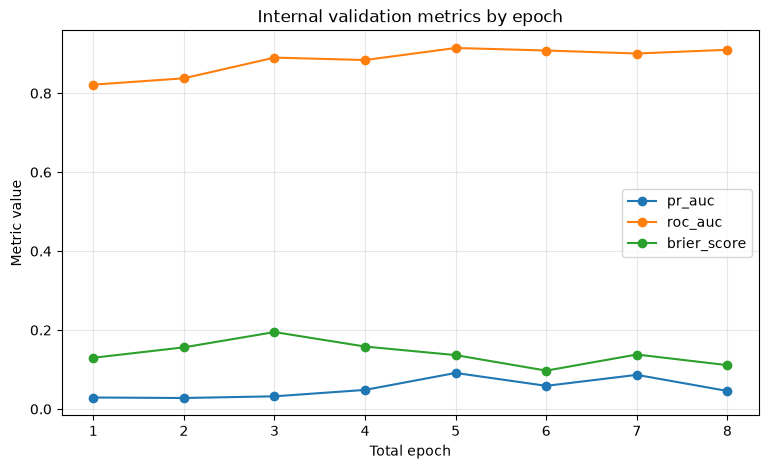

In [40]:
# ---------------------------------------------------------------------
# Internal validation metrics
# ---------------------------------------------------------------------

history_plot = internal_history[
    [
        "total_epoch",
        "stage",
        "pr_auc",
        "roc_auc",
        "brier_score",
    ]
].copy()

ax = history_plot.set_index("total_epoch")[
    [
        "pr_auc",
        "roc_auc",
        "brier_score",
    ]
].plot(
    marker="o",
    figsize=(9, 5),
    title="Internal validation metrics by epoch",
)

ax.set_xlabel("Total epoch")
ax.set_ylabel("Metric value")
ax.grid(alpha=0.3)

plt.show()

> **Internal training loss by epoch**

The training-loss trajectory is shown together with the transition between
classifier warm-up and partial fine-tuning.

This visualization is diagnostic and does not affect checkpoint selection.

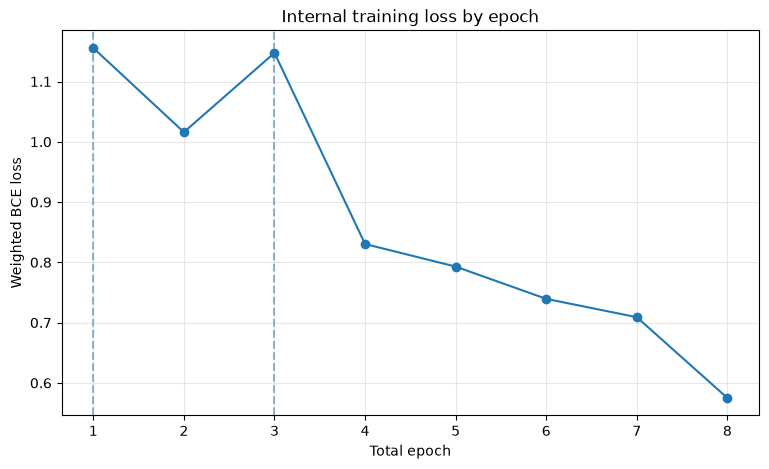

In [41]:
# ---------------------------------------------------------------------
# Internal training stage
# ---------------------------------------------------------------------

stage_history = internal_history[
    [
        "total_epoch",
        "stage",
        "train_loss",
    ]
].copy()

ax = stage_history.set_index("total_epoch")[
    "train_loss"
].plot(
    marker="o",
    figsize=(9, 5),
    title="Internal training loss by epoch",
)

ax.set_xlabel("Total epoch")
ax.set_ylabel("Weighted BCE loss")
ax.grid(alpha=0.3)

# Mark the transition between training stages.
stage_changes = (
    stage_history["stage"]
    .ne(stage_history["stage"].shift())
)

for epoch, stage in zip(
    stage_history.loc[stage_changes, "total_epoch"],
    stage_history.loc[stage_changes, "stage"],
):
    ax.axvline(
        epoch,
        linestyle="--",
        alpha=0.5,
    )

plt.show()

### **Final model refit**

After internal model development, a completely fresh CNN is initialized using the same architecture, initialization strategy, dropout configuration and training configuration.

For the current TFM experiments, this refit follows the **ImageNet transfer-learning protocol** selected during internal model development.

The selected training schedule is fixed before the refit. No validation-based checkpoint selection or early stopping is performed.

The final model is trained on the complete selected official training split. Because the fitting dataset is now larger than the internal training subset, the final class weight is calculated from the targets stored in `full_train_store`, which correspond exactly to the complete selected training split used for the final refit.

The internal checkpoint weights are deliberately not transferred to the final model. This keeps the final fitting stage independent of the internal checkpoint parameters.

The current `fit_final_model()` implementation also accepts the optional `scratch` initialization. In that case, the complete network remains trainable throughout the two configured stages. This provides a reusable implementation path, but the corresponding optimization protocol has not been validated as a dedicated from-scratch methodology in this TFM.

A dedicated scratch-specific final-fitting strategy can therefore be implemented in future work if experiments with randomly initialized CNNs are required.


In [42]:
# ---------------------------------------------------------------------
# Full selected training dataset and DataLoader
# ---------------------------------------------------------------------

FINAL_TRAIN_GENERATOR = torch.Generator()
FINAL_TRAIN_GENERATOR.manual_seed(RANDOM_STATE)

full_train_loader = DataLoader(
    full_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    worker_init_fn=seed_worker,
    generator=FINAL_TRAIN_GENERATOR,
    **DATALOADER_KWARGS,
)

print(f"Full-training observations: {len(full_train_dataset):,}")
print(f"Full-training batches: {len(full_train_loader):,}")

Full-training observations: 305,024
Full-training batches: 2,383


In [43]:
# ---------------------------------------------------------------------
# Final-fit class weighting
# ---------------------------------------------------------------------

assert len(full_train_dataset) == len(df_train)

assert np.array_equal(
    full_train_store.targets.astype(int),
    df_train[TARGET].to_numpy(dtype=int),
)

full_train_pos_weight = compute_pos_weight(
    labels=full_train_store.targets,
    mode=POS_WEIGHT_MODE,
)

final_ratio = (
    (full_train_store.targets == 0).sum()
    / (full_train_store.targets == 1).sum()
)

print(f"Full-train negative / positive ratio: {final_ratio:.3f}")
print(f"Final full_train_pos_weight ({POS_WEIGHT_MODE}): {full_train_pos_weight:.3f}")

Full-train negative / positive ratio: 374.645
Final full_train_pos_weight (full): 374.645


In [44]:
# ---------------------------------------------------------------------
# Final model refit
# ---------------------------------------------------------------------

def fit_final_model(
    train_loader: DataLoader,
    pos_weight: float,
    schedule: dict[str, int],
) -> tuple[
    nn.Module,
    pd.DataFrame,
]:
    """
    Refit a fresh CNN using the internally selected training schedule.

    No validation data are accessed during this refit. The number of
    epochs for each optimization stage is fixed before training begins.

    For ImageNet initialization, the stages correspond to classifier
    warm-up and partial fine-tuning. For scratch initialization, they
    correspond to full-network training and low-learning-rate continuation.
    """

    # -----------------------------------------------------------------
    # Reproducibility
    # -----------------------------------------------------------------

    set_seed(RANDOM_STATE)

    FINAL_TRAIN_GENERATOR.manual_seed(RANDOM_STATE)

    # -----------------------------------------------------------------
    # Validate schedule
    # -----------------------------------------------------------------

    required_schedule_keys = {
        "warmup_epochs",
        "fine_tune_epochs",
    }

    missing_keys = required_schedule_keys.difference(schedule.keys())

    if missing_keys:
        raise KeyError(f"Schedule is missing keys: {sorted(missing_keys)}")

    warmup_epochs = int(schedule["warmup_epochs"])
    fine_tune_epochs = int(schedule["fine_tune_epochs"])

    if warmup_epochs < 0:
        raise ValueError("warmup_epochs cannot be negative.")

    if fine_tune_epochs < 0:
        raise ValueError("fine_tune_epochs cannot be negative.")

    if warmup_epochs == 0 and fine_tune_epochs == 0:
        raise ValueError("The selected schedule contains no training epochs.")

    # -----------------------------------------------------------------
    # Fresh model
    # -----------------------------------------------------------------

    model = build_model(
        architecture=MODEL_ARCHITECTURE,
        pretrained=PRETRAINED,
        device=DEVICE,
    )

    # -----------------------------------------------------------------
    # Final-fit criterion
    # -----------------------------------------------------------------

    criterion = make_criterion(
        pos_weight=pos_weight,
        device=DEVICE,
    )

    # One scaler is used throughout the complete final refit.
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    # scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    history = []
    total_epoch = 0

    # -----------------------------------------------------------------
    # Phase 1
    # -----------------------------------------------------------------

    # ImageNet -> classifier warm-up
    # Scratch  -> full-network training

    if warmup_epochs > 0:

        configure_trainable_layers(
            model=model,
            architecture=MODEL_ARCHITECTURE,
            n_unfrozen_blocks=0,
            train_all_layers=TRAIN_ALL_LAYERS,
        )

        optimizer = make_optimizer(
            model=model,
            learning_rate=WARMUP_LR,
        )

        for stage_epoch in range(
            1,
            warmup_epochs + 1,
        ):

            total_epoch += 1

            train_loss = train_one_epoch(
                model=model,
                loader=train_loader,
                optimizer=optimizer,
                criterion=criterion,
                device=DEVICE,
                architecture=MODEL_ARCHITECTURE,
                n_unfrozen_blocks=0,
                train_all_layers=TRAIN_ALL_LAYERS,
                scaler=scaler,
            )

            history.append(
                {
                    "stage": STAGE_1_NAME,
                    "stage_epoch": stage_epoch,
                    "total_epoch": total_epoch,
                    "train_loss": train_loss,
                }
            )

            print(f"[final {STAGE_1_NAME} {stage_epoch:02d}] loss={train_loss:.5f}")

    # -----------------------------------------------------------------
    # Phase 2
    # -----------------------------------------------------------------

    # ImageNet -> partial fine-tuning
    # Scratch  -> low-learning-rate continuation

    if fine_tune_epochs > 0:

        configure_trainable_layers(
            model=model,
            architecture=MODEL_ARCHITECTURE,
            n_unfrozen_blocks=UNFREEZE_LAST_N_BLOCKS,
            train_all_layers=TRAIN_ALL_LAYERS,
        )

        # IMPORTANT:
        # A new optimizer is required because the set of trainable
        # parameters has changed.
        optimizer = make_optimizer(
            model=model,
            learning_rate=FINE_TUNE_LR,
        )

        for stage_epoch in range(
            1,
            fine_tune_epochs + 1,
        ):

            total_epoch += 1

            train_loss = train_one_epoch(
                model=model,
                loader=train_loader,
                optimizer=optimizer,
                criterion=criterion,
                device=DEVICE,
                architecture=MODEL_ARCHITECTURE,
                n_unfrozen_blocks=UNFREEZE_LAST_N_BLOCKS,
                train_all_layers=TRAIN_ALL_LAYERS,
                scaler=scaler,
            )

            history.append(
                {
                    "stage": STAGE_2_NAME,
                    "stage_epoch": stage_epoch,
                    "total_epoch": total_epoch,
                    "train_loss": train_loss,
                }
            )

            print(f"[final {STAGE_2_NAME} {stage_epoch:02d}] loss={train_loss:.5f}")

    return (model, pd.DataFrame(history))

> **Run the final model refit**

The final model is now refitted on the complete selected training split using the fixed schedule obtained during internal model development.

For the current experiment, the model uses the configured **ImageNet transfer-learning initialization**.

A fresh model and a training-specific class weight are used. No validation predictions, checkpoint selection or early stopping are performed during this stage.


In [45]:
# ---------------------------------------------------------------------
# Final model refit
# ---------------------------------------------------------------------

final_model, final_training_history = fit_final_model(
    train_loader=full_train_loader,
    pos_weight=full_train_pos_weight,
    schedule=selected_schedule,
)

[final warmup 01] loss=1.15247
[final warmup 02] loss=1.00763
[final fine_tune 01] loss=1.08558
[final fine_tune 02] loss=0.78687
[final fine_tune 03] loss=0.75359


> **Final model training history**

The final training history is retained as an optimization diagnostic.

Because no validation partition is used during final refitting, only the
training loss is recorded. This history is not used for model selection or
schedule modification.

In [46]:
# ---------------------------------------------------------------------
# Final training history
# ---------------------------------------------------------------------

print("\nFinal training history:")
display(final_training_history)


Final training history:


,stage,stage_epoch,total_epoch,train_loss
0,warmup,1,1,1.1525
1,warmup,2,2,1.0076
2,fine_tune,1,3,1.0856
3,fine_tune,2,4,0.7869
4,fine_tune,3,5,0.7536


> **Final training loss by epoch**

The training-loss trajectory provides a diagnostic view of optimization across
the fixed warm-up and fine-tuning schedule.

The transition between training stages is indicated in the plot.

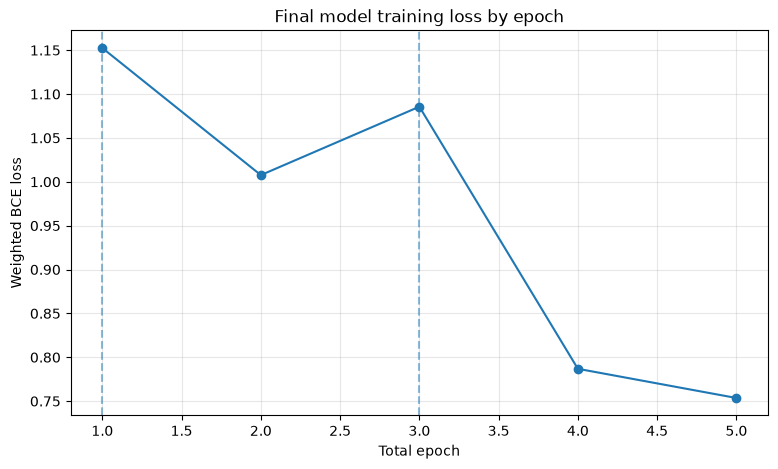

In [47]:
# ---------------------------------------------------------------------
# Final training loss
# ---------------------------------------------------------------------

final_history_plot = final_training_history[
    [
        "total_epoch",
        "stage",
        "train_loss",
    ]
].copy()

ax = final_history_plot.set_index("total_epoch")[
    "train_loss"
].plot(
    marker="o",
    figsize=(9, 5),
    title="Final model training loss by epoch",
)

ax.set_xlabel("Total epoch")
ax.set_ylabel("Weighted BCE loss")
ax.grid(alpha=0.3)

# Mark the transition between training stages.
stage_changes = (
    final_history_plot["stage"]
    .ne(final_history_plot["stage"].shift())
)

for epoch, stage in zip(
    final_history_plot.loc[stage_changes, "total_epoch"],
    final_history_plot.loc[stage_changes, "stage"],
):
    ax.axvline(
        epoch,
        linestyle="--",
        alpha=0.5,
    )

plt.show()

## **Save final model and experiment configuration**

The final model obtained after refitting is saved using the project's
`save_model()` utility.

The model directory also stores the information required to reproduce and audit
the experiment independently of the notebook runtime:

- the exact selected training lesion identifiers;
- the exact internal train/validation assignment used during model development;
- the internal validation history;
- the final refit history;
- the selected training schedule;
- the model architecture and initialization strategy;
- the class-weighting configuration and values;
- the optimization and fine-tuning configuration;
- the image preprocessing and augmentation settings.

The internal best checkpoint is not used as the final model. Only the freshly
refitted model is saved as the model associated with the experiment.

The official external validation and test partitions are not used to define
the saved model or its training schedule.

In [48]:
# ---------------------------------------------------------------------
# Save final model and experiment artefacts
# ---------------------------------------------------------------------

model_directory = save_model(
    model=final_model,
    model_name=MODEL_NAME,
    model_type=2,
)

model_directory = Path(model_directory)

print(f"Final model directory: {model_directory}")

Model saved in: /content/drive/MyDrive/TFM/my-image-classifier/data/models/resnet50_image_h1_full_train_imagenet/model_state_dict.pt
Final model directory: /content/drive/MyDrive/TFM/my-image-classifier/data/models/resnet50_image_h1_full_train_imagenet


In [49]:
# ---------------------------------------------------------------------
# Save exact training lesion IDs
# ---------------------------------------------------------------------

training_ids_path = (
    model_directory / "training_lesion_ids.csv"
)

df_train[[ID_COLUMN]].to_csv(
    training_ids_path,
    index=False,
)

print(f"Training IDs saved to: {training_ids_path}")

Training IDs saved to: /content/drive/MyDrive/TFM/my-image-classifier/data/models/resnet50_image_h1_full_train_imagenet/training_lesion_ids.csv


In [50]:
# ---------------------------------------------------------------------
# Save exact internal split assignment
# ---------------------------------------------------------------------

internal_split_path = (model_directory / "internal_split_lesion_ids.csv")

internal_split_ids.to_csv(
    internal_split_path,
    index=False,
)

print(f"Internal split assignment saved to: {internal_split_path}")

Internal split assignment saved to: /content/drive/MyDrive/TFM/my-image-classifier/data/models/resnet50_image_h1_full_train_imagenet/internal_split_lesion_ids.csv


In [51]:
# ---------------------------------------------------------------------
# Save training histories
# ---------------------------------------------------------------------

internal_history_path = (model_directory / "internal_training_history.csv")

internal_history.to_csv(
    internal_history_path,
    index=False,
)

final_history_path = (model_directory / "final_training_history.csv")

final_training_history.to_csv(
    final_history_path,
    index=False,
)

print(f"Internal history saved to: {internal_history_path}")
print(f"Final history saved to: {final_history_path}")

Internal history saved to: /content/drive/MyDrive/TFM/my-image-classifier/data/models/resnet50_image_h1_full_train_imagenet/internal_training_history.csv
Final history saved to: /content/drive/MyDrive/TFM/my-image-classifier/data/models/resnet50_image_h1_full_train_imagenet/final_training_history.csv


## **Experiment configuration**

The complete experimental configuration is stored alongside the final model.

The configuration records both the predefined settings and the decisions made
during internal model development, including the selected training schedule.

This record distinguishes:

- the configured maximum training duration;
- the effective warm-up and fine-tuning duration selected internally;
- the internal and final class weights;
- the architecture and initialization strategy;
- the architecture-specific fine-tuning configuration;
- the optimization and augmentation parameters.

The configuration therefore provides a reproducible description of the model
run without requiring the notebook state to be reconstructed manually.

In [52]:
# ---------------------------------------------------------------------
# Experiment configuration
# ---------------------------------------------------------------------

def to_python_scalar(value):
    """Convert NumPy scalar values to native Python values."""

    if isinstance(value, np.generic):
        return value.item()

    return value


experiment_configuration = {
    # -------------------------------------------------------------
    # Experiment identity
    # -------------------------------------------------------------
    "hypothesis": HYPOTHESIS,
    "hypothesis_description": HYPOTHESIS_DESCRIPTION,
    "target": TARGET,
    "model_name": MODEL_NAME,

    # -------------------------------------------------------------
    # CNN architecture
    # -------------------------------------------------------------
    "architecture": MODEL_ARCHITECTURE,
    "initialization": CNN_INITIALIZATION,
    "pretrained": PRETRAINED,

    "training_regime": (
        "from_scratch_full_network"
        if TRAIN_ALL_LAYERS
        else "imagenet_transfer_learning"
    ),
    "train_all_layers": TRAIN_ALL_LAYERS,
    "stage_definitions": (
        {
            "stage_1": "full_network_training",
            "stage_2": "low_learning_rate_continuation",
        }
        if TRAIN_ALL_LAYERS
        else {
            "stage_1": "classifier_warmup",
            "stage_2": "partial_fine_tuning",
        }
    ),
    "head dropout": DROPOUT,

    # Transfer Learning ImageNet
    "unfreeze_strategy": (
        ARCH_CONFIG["unfreeze_strategy"]
    ),
    "unfreeze_last_n_blocks": (
        UNFREEZE_LAST_N_BLOCKS
    ),

    # Estrategy for execution
    "effective_feature_training": (
        "all_layers"
        if TRAIN_ALL_LAYERS
        else ARCH_CONFIG["unfreeze_strategy"]
    ),

    # -------------------------------------------------------------
    # Image configuration
    # -------------------------------------------------------------
    "image_size": IMAGE_SIZE,
    "image_manifest": str(image_manifest_path),
    "image_timestamp_setting": IMAGE_TIMESTAMP,

    # -------------------------------------------------------------
    # Dataset sizes
    # -------------------------------------------------------------
    "train_full_lesions": len(df_train_full),
    "train_used_lesions": len(df_train),
    "validation_lesions": len(df_validation),
    "test_metadata_lesions": len(df_test),

    "train_max_lesions": TRAIN_MAX_LESIONS,
    "train_subsample_random_state": (
        TRAIN_SUBSAMPLE_RANDOM_STATE
    ),

    # -------------------------------------------------------------
    # Reproducibility
    # -------------------------------------------------------------
    "random_state": RANDOM_STATE,
    "device": str(DEVICE),
    "pytorch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
    "cuda_version": (
        torch.version.cuda
        if torch.cuda.is_available()
        else None
    ),

    # -------------------------------------------------------------
    # Internal model development
    # -------------------------------------------------------------
    "internal_holdout": {
        "n_folds": N_INTERNAL_FOLDS,
        "selected_fold_index": INTERNAL_FOLD_INDEX,
        "train_lesions": internal_train_size,
        "validation_lesions": internal_validation_size,
        "best_metrics": {
            key: to_python_scalar(value)
            for key, value in internal_best_metrics.items()
        },
    },

    # -------------------------------------------------------------
    # Class imbalance
    # -------------------------------------------------------------
    "class_imbalance": {
        "pos_weight_mode": POS_WEIGHT_MODE,
        "internal_pos_weight": (
            internal_pos_weight
        ),
        "final_pos_weight": (
            full_train_pos_weight
        ),
    },

    # -------------------------------------------------------------
    # Optimization
    # -------------------------------------------------------------
    "training": {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "persistent_workers": PERSISTENT_WORKERS,
        "prefetch_factor": DATALOADER_KWARGS.get(
            "prefetch_factor",
            None,
        ),
        "pin_memory": PIN_MEMORY,
        "mixed_precision": USE_AMP,

        "warmup_learning_rate": WARMUP_LR,
        "fine_tune_learning_rate": FINE_TUNE_LR,
        "weight_decay": WEIGHT_DECAY,

        "configured_warmup_epochs": WARMUP_EPOCHS,
        "configured_max_fine_tune_epochs": (
            MAX_FINE_TUNE_EPOCHS
        ),
        "early_stopping_patience": (
            EARLY_STOPPING_PATIENCE
        ),

        "selected_final_schedule": (
            selected_schedule
        ),
    },

    # -------------------------------------------------------------
    # Evaluation configuration
    # -------------------------------------------------------------
    "evaluation": {
        "primary_metric": PRIMARY_METRIC,
        "secondary_metrics": SECONDARY_METRICS,
        "target_sensitivity": TARGET_SENSITIVITY,
    },

    # -------------------------------------------------------------
    # Augmentation and normalization
    # -------------------------------------------------------------
    "augmentation": {
        "horizontal_flip_probability": 0.5,
        "vertical_flip_probability": 0.5,
        "rotation_degrees": 15,
        "brightness": 0.10,
        "contrast": 0.10,
        "saturation": 0.05,
        "imagenet_mean": list(IMAGENET_MEAN),
        "imagenet_std": list(IMAGENET_STD),
    },
}

experiment_config_path = (
    model_directory / "training_configuration.json"
)

with experiment_config_path.open(
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        experiment_configuration,
        file,
        indent=2,
        ensure_ascii=False,
    )

print(
    f"Training configuration saved to: "
    f"{experiment_config_path}"
)

Training configuration saved to: /content/drive/MyDrive/TFM/my-image-classifier/data/models/resnet50_image_h1_full_train_imagenet/training_configuration.json


# **3. Model Evaluation**

The evaluation stage is performed only after the complete CNN model-development and final-refit procedures have been completed.

During internal model development, the internal validation partition was used exclusively to select the training schedule according to the predefined lexicographic hierarchy:

**PR-AUC → ROC-AUC → lower Brier score.**

The selected schedule was then applied to a completely new model initialized according to the selected CNN configuration and refitted using the complete selected training split.

The final refitted model is now evaluated on:

- the complete selected training split, for descriptive assessment of model fit; and
- the official external validation split, for assessment of generalization.

The evaluation uses the deterministic evaluation transform rather than the training augmentation pipeline.

The continuous positive-class probabilities generated by the final model are passed to the project's common `evaluate()` pipeline. This pipeline calculates the predefined threshold-independent performance and probability-quality metrics and selects the operating threshold exclusively from the external validation partition according to the predefined target sensitivity.

No model architecture, initialization strategy, training schedule, optimizer configuration or class-weighting strategy is modified at this stage.

The official test partition is intentionally not evaluated in this notebook. It remains completely untouched and is reserved for the subsequent multimodal modelling stage.

## **Generate final train and external-validation probabilities**

The final refitted model is evaluated on the complete selected training split
and on the official external validation partition.

A deterministic evaluation transform is used for both partitions. No training
augmentation is applied during prediction.

`predict_loader()` converts the model's output logits into positive-class
probabilities using the sigmoid transformation and returns the corresponding
lesion identifiers.

The training DataLoader is recreated with `shuffle=False` so that the generated
probabilities have a deterministic association with their lesion identifiers.

The external validation predictions are generated only after the final model
and its training schedule have been fixed.

In [53]:
# ---------------------------------------------------------------------
# Deterministic evaluation DataLoaders
# ---------------------------------------------------------------------

full_train_prediction_loader = DataLoader(
    full_train_prediction_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    **DATALOADER_KWARGS,
)

full_validation_prediction_loader = DataLoader(
    full_validation_prediction_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    **DATALOADER_KWARGS,
)

print(f"Training evaluation observations: {len(full_train_prediction_dataset):,}")
print(f"Training evaluation batches: {len(full_train_prediction_loader):,}")
print(f"External validation observations: {len(full_validation_prediction_dataset):,}")
print(f"External validation batches: {len(full_validation_prediction_loader):,}")

Training evaluation observations: 305,024
Training evaluation batches: 2,383
External validation observations: 38,131
External validation batches: 298


The deterministic prediction datasets reuse the shared full-training and external-validation image stores created before intermediate image DataFrames are released.

## **Generate final model probabilities**

The final refitted CNN is evaluated in inference mode using the deterministic
evaluation transform.

No training-time augmentation, parameter updates or optimization steps are
performed during this stage.

The training and external validation partitions are processed with
`shuffle=False` so that the lesion identifiers returned by `predict_loader()`
remain deterministically associated with their predicted probabilities.

The resulting probabilities are retained as continuous positive-class
probabilities. No classification threshold is applied here.

Threshold selection is deferred to the common evaluation pipeline, where the
operating threshold is determined exclusively from the external validation
partition.

In [54]:
# ---------------------------------------------------------------------
# Generate final predictions
# ---------------------------------------------------------------------

(
    train_y_true,
    train_probabilities,
    train_lesion_ids,
) = predict_loader(
    model=final_model,
    loader=full_train_prediction_loader,
    device=DEVICE,
)

(
    validation_y_true,
    validation_probabilities,
    validation_lesion_ids,
) = predict_loader(
    model=final_model,
    loader=full_validation_prediction_loader,
    device=DEVICE,
)

print(f"Train predictions: {len(train_probabilities):,}")
print(f"Validation predictions: {len(validation_probabilities):,}")

Train predictions: 305,024
Validation predictions: 38,131


In [55]:
# ---------------------------------------------------------------------
# Prediction integrity checks
# ---------------------------------------------------------------------

assert len(train_y_true) == len(df_train)
assert len(train_probabilities) == len(df_train)
assert len(train_lesion_ids) == len(df_train)

assert len(validation_y_true) == len(df_validation)
assert len(validation_probabilities) == len(df_validation)
assert len(validation_lesion_ids) == len(df_validation)

assert len(set(train_lesion_ids)) == len(train_lesion_ids)
assert len(set(validation_lesion_ids)) == len(validation_lesion_ids)

assert np.isfinite(train_probabilities).all()
assert np.isfinite(validation_probabilities).all()

assert (np.asarray(train_probabilities).min() >= 0.0)
assert (np.asarray(train_probabilities).max() <= 1.0)

assert (np.asarray(validation_probabilities).min() >= 0.0)
assert (np.asarray(validation_probabilities).max() <= 1.0)

print("Prediction integrity checks: OK")

Prediction integrity checks: OK


## **Prepare prediction tables**

The common `evaluate()` function operates on prediction tables containing the
lesion identifier and the predicted positive-class probability.

The tables are constructed from the identifiers returned by `predict_loader()`
rather than relying on an implicit correspondence with dataframe row order.

This makes the prediction-to-lesion association explicit and auditable.

In [56]:
# ---------------------------------------------------------------------
# Prediction probability tables
# ---------------------------------------------------------------------

df_train_predictions = pd.DataFrame(
    {
        ID_COLUMN: train_lesion_ids,
        "probability": train_probabilities,
    }
)

df_validation_predictions = pd.DataFrame(
    {
        ID_COLUMN: validation_lesion_ids,
        "probability": validation_probabilities,
    }
)

print("Training predictions:")
display(df_train_predictions.head())

print("External validation predictions:")
display(df_validation_predictions.head())

Training predictions:


,isic_id,probability
0,ISIC_0015670,0.0643
1,ISIC_0015845,0.7690
2,ISIC_0015864,0.0029
3,ISIC_0015902,0.0618
4,ISIC_0024200,0.0026


External validation predictions:


,isic_id,probability
0,ISIC_0052122,0.0707
1,ISIC_0052259,0.1263
2,ISIC_0052332,0.0047
3,ISIC_0073261,0.0004
4,ISIC_0073412,0.0051


## **Train and external-validation evaluation**

The final refitted model is evaluated using the project's common `evaluate()`
pipeline.

The training and external validation probabilities are evaluated after all
model-development decisions have been fixed.

The evaluation pipeline provides the project's standard performance and
probability-quality metrics and determines the operating threshold exclusively
from the external validation partition according to the predefined target
sensitivity.

This threshold is selected only after architecture, initialization, class
weighting strategy, training schedule and final model fitting have been fixed.

The test partition is intentionally excluded from this notebook because it is
reserved for the subsequent multimodal modelling stage.

In [57]:
# ---------------------------------------------------------------------
# Final train and external-validation evaluation
# ---------------------------------------------------------------------

# TARGET_SENSITIVITY = 0.95

results = evaluate(
    df_train_predictions=df_train_predictions,
    df_validation_predictions=df_validation_predictions,
    df_train=df_train,
    df_validation=df_validation,
    hypothesis=HYPOTHESIS,
    model_directory=model_directory,
    target_sensitivity=TARGET_SENSITIVITY,
)

display(results["summary"])

TRAIN AND VALIDATION EVALUATION
Model: resnet50_image_h1_full_train_imagenet
Hypothesis 1: Lesion recommended for biopsy
------------------------------------------------------------------------
                                   Train      Validation
Lesions                          305,024          38,131
Patients                             784              94
Lesion prevalence                 0.0027          0.0026
------------------------------------------------------------------------
PR-AUC                            0.0996          0.0692
ROC-AUC                           0.9450          0.9055
Brier score                       0.1380          0.1190
------------------------------------------------------------------------
Selected validation threshold: 0.081333
Target sensitivity: 0.950
------------------------------------------------------------------------
Sensitivity                       0.9938          0.9505
Specificity                       0.5336          0.5950
PPV     

,metric,train,validation
0,total_lesions,"305,024.0000","38,131.0000"
1,total_patients,784.0000,94.0000
2,positive_lesions,812.0000,101.0000
3,negative_lesions,"304,212.0000","38,030.0000"
4,patients_with_positive_lesion,497.0000,68.0000
5,lesion_prevalence,0.0027,0.0026
6,patient_prevalence,0.6339,0.7234
7,pr_auc,0.0996,0.0692
8,roc_auc,0.9450,0.9055
9,brier_score,0.1380,0.1190


## **Evaluation figures**

The common evaluation pipeline also generates the standard diagnostic figures
for the final CNN experiment.

These figures are produced from the final model predictions and the
validation-selected operating point. They are stored in the model-specific
experiment directory and displayed below.

No additional threshold or model-selection criterion is introduced by these
figures.

### Precision Recall Curve

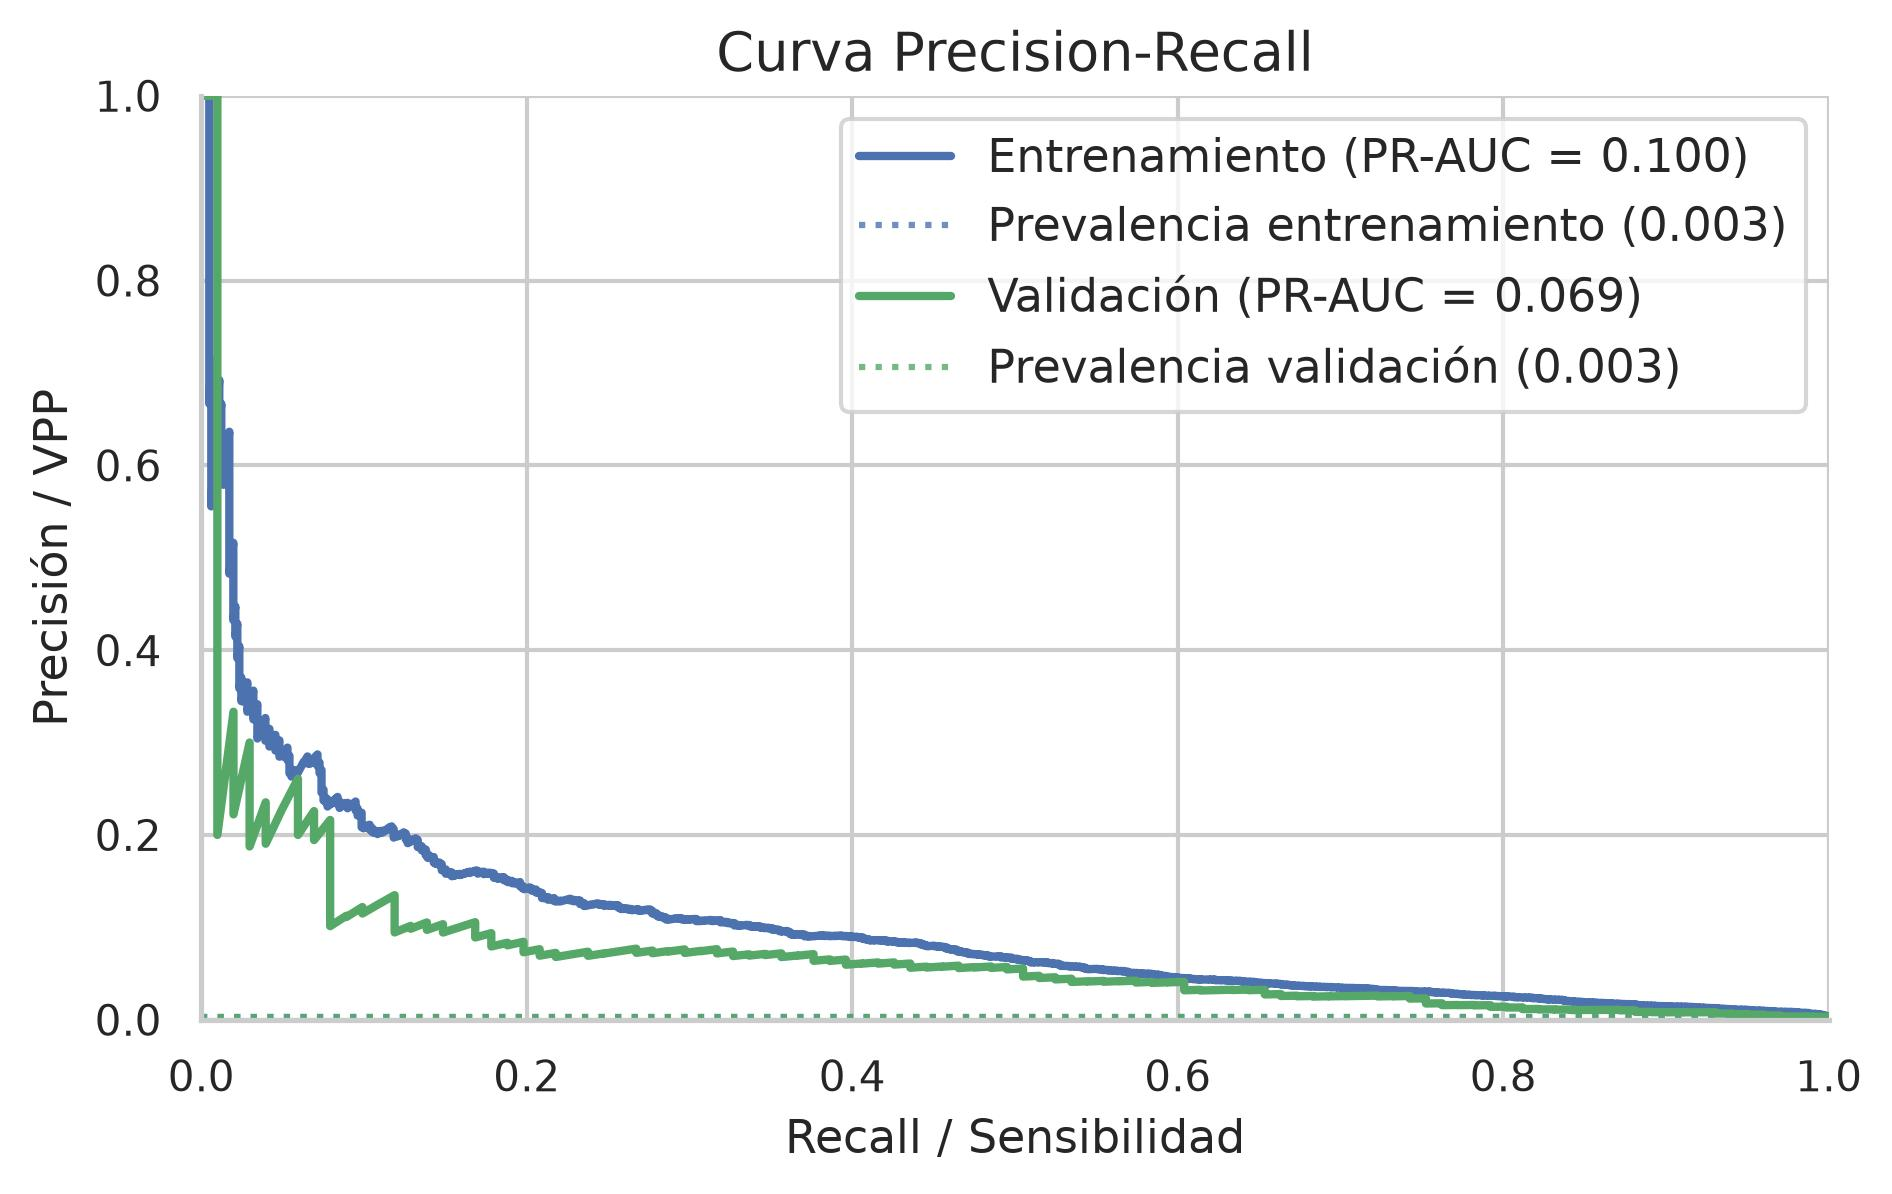

### Roc Curve

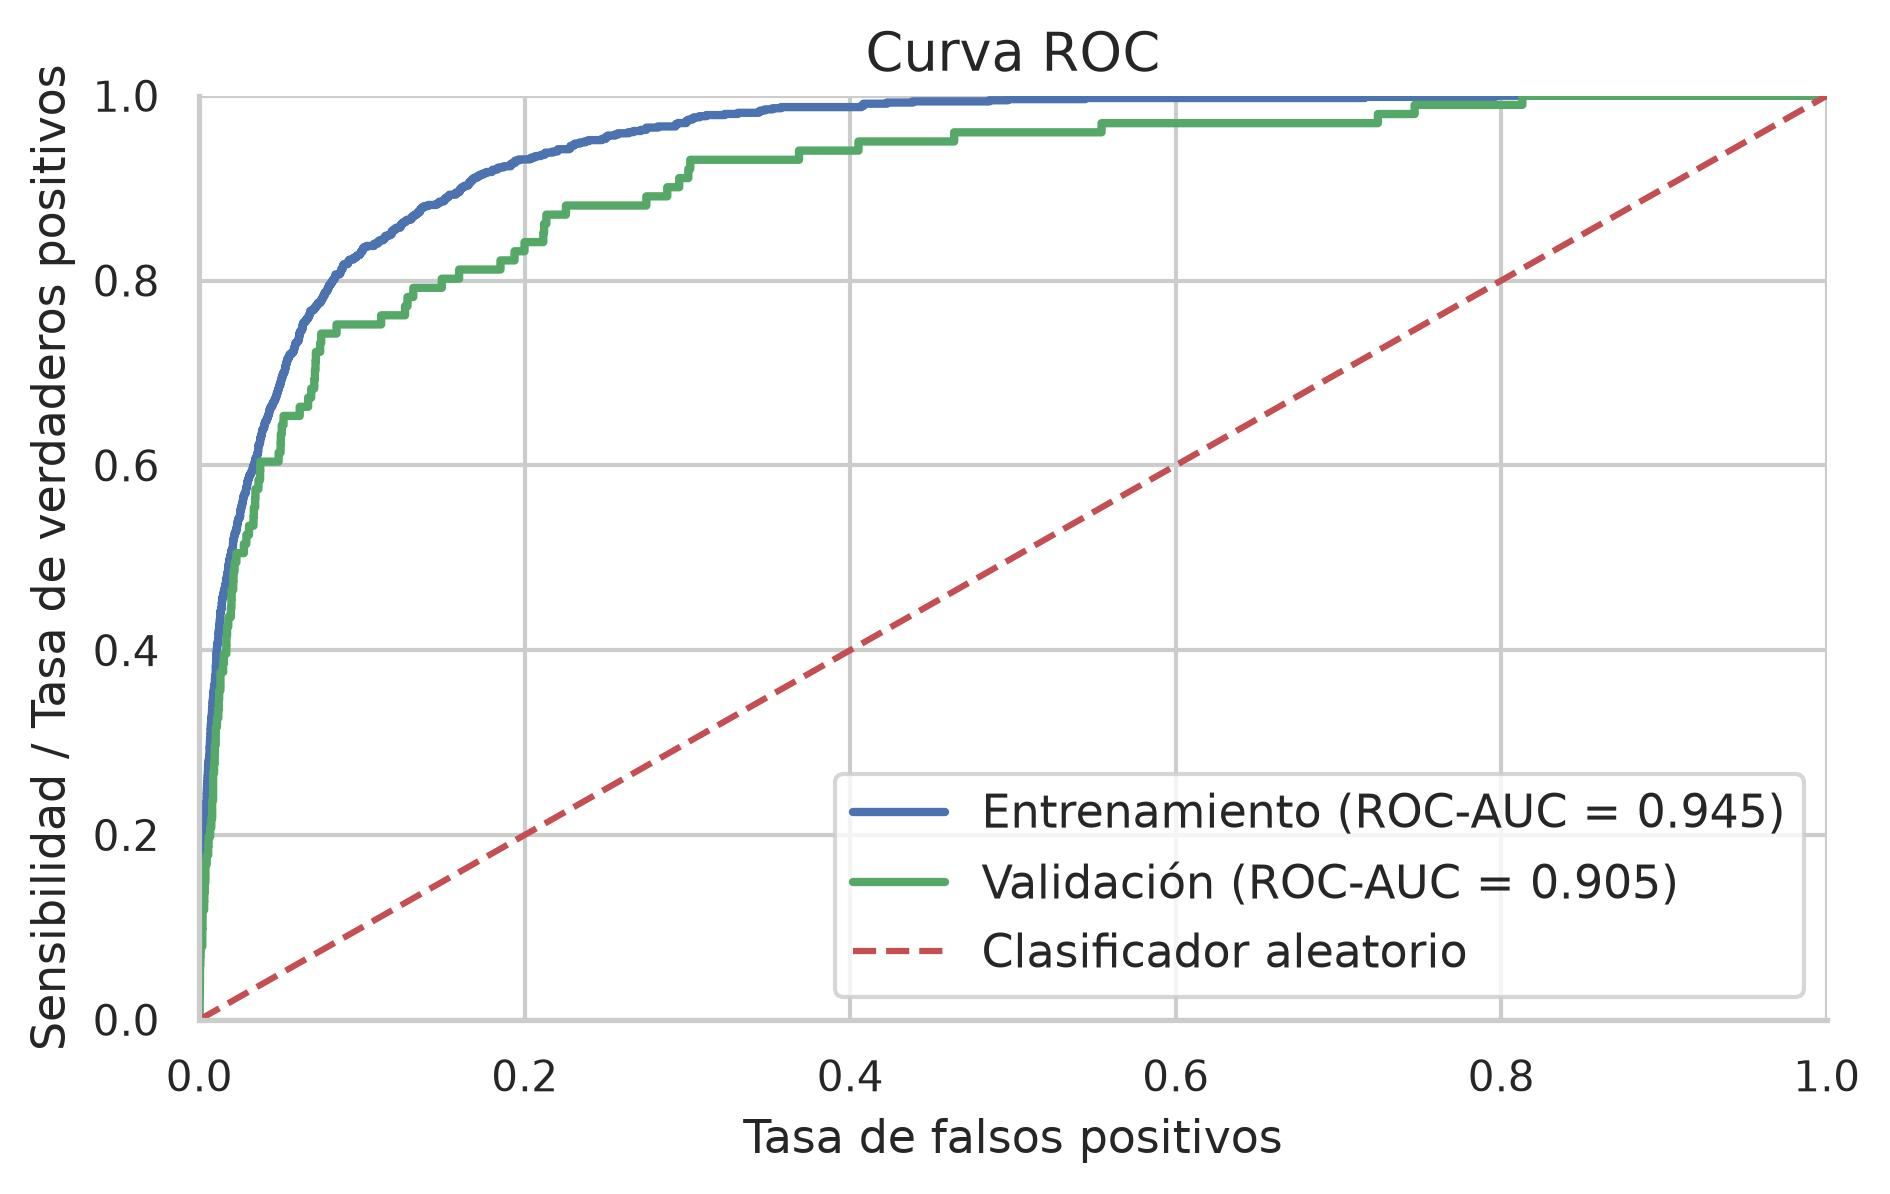

### Pr Roc Curves

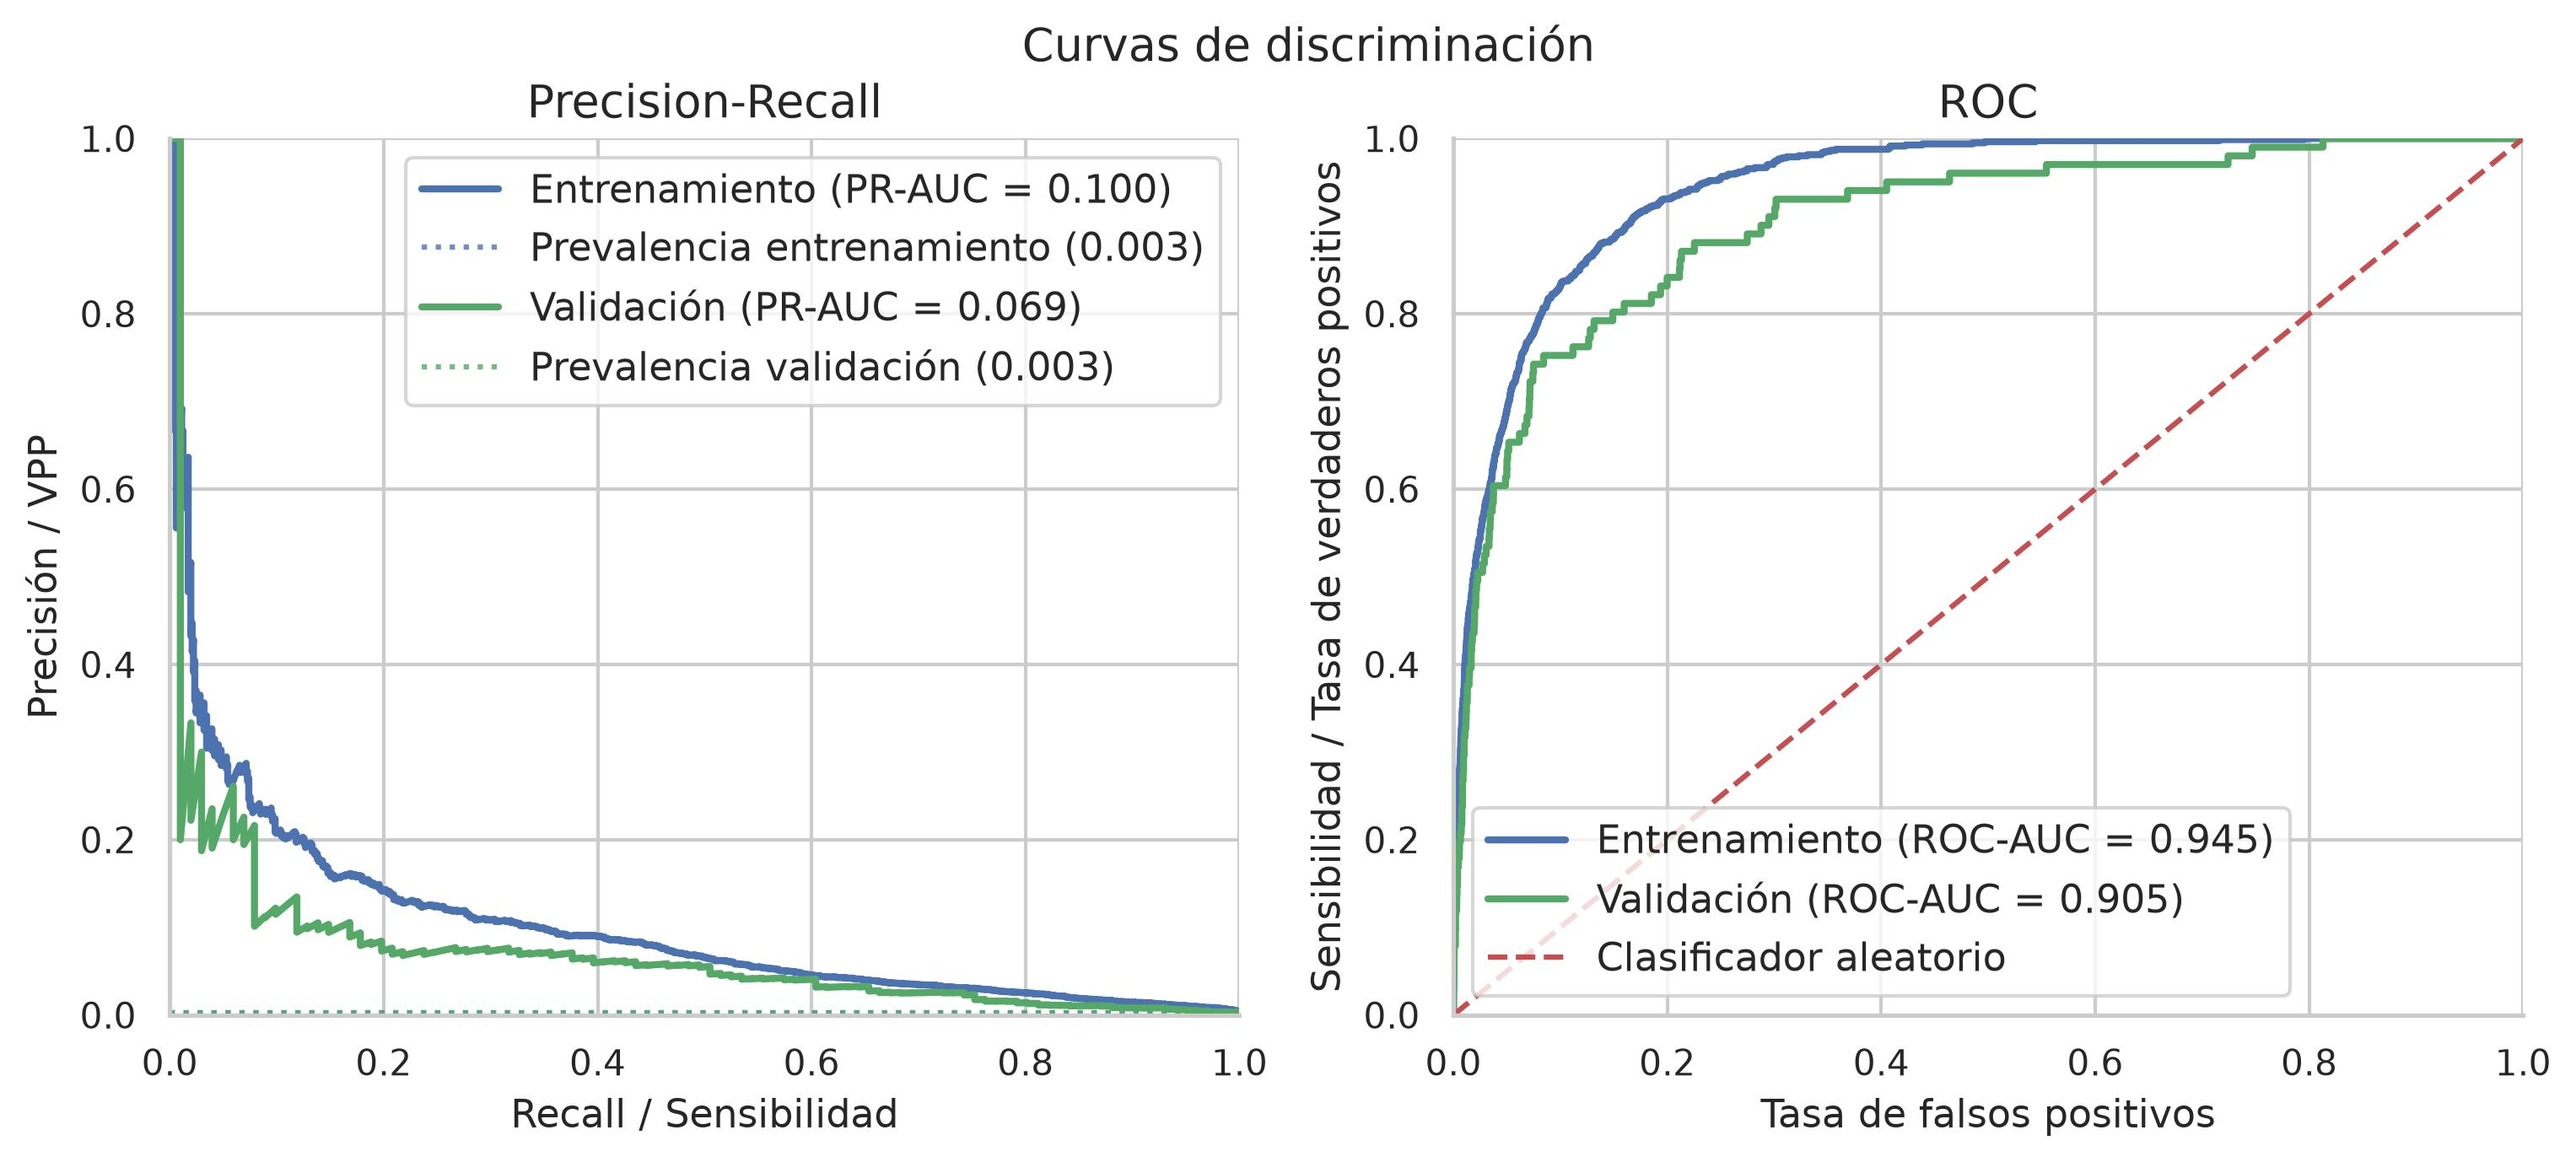

### Clinical Summary

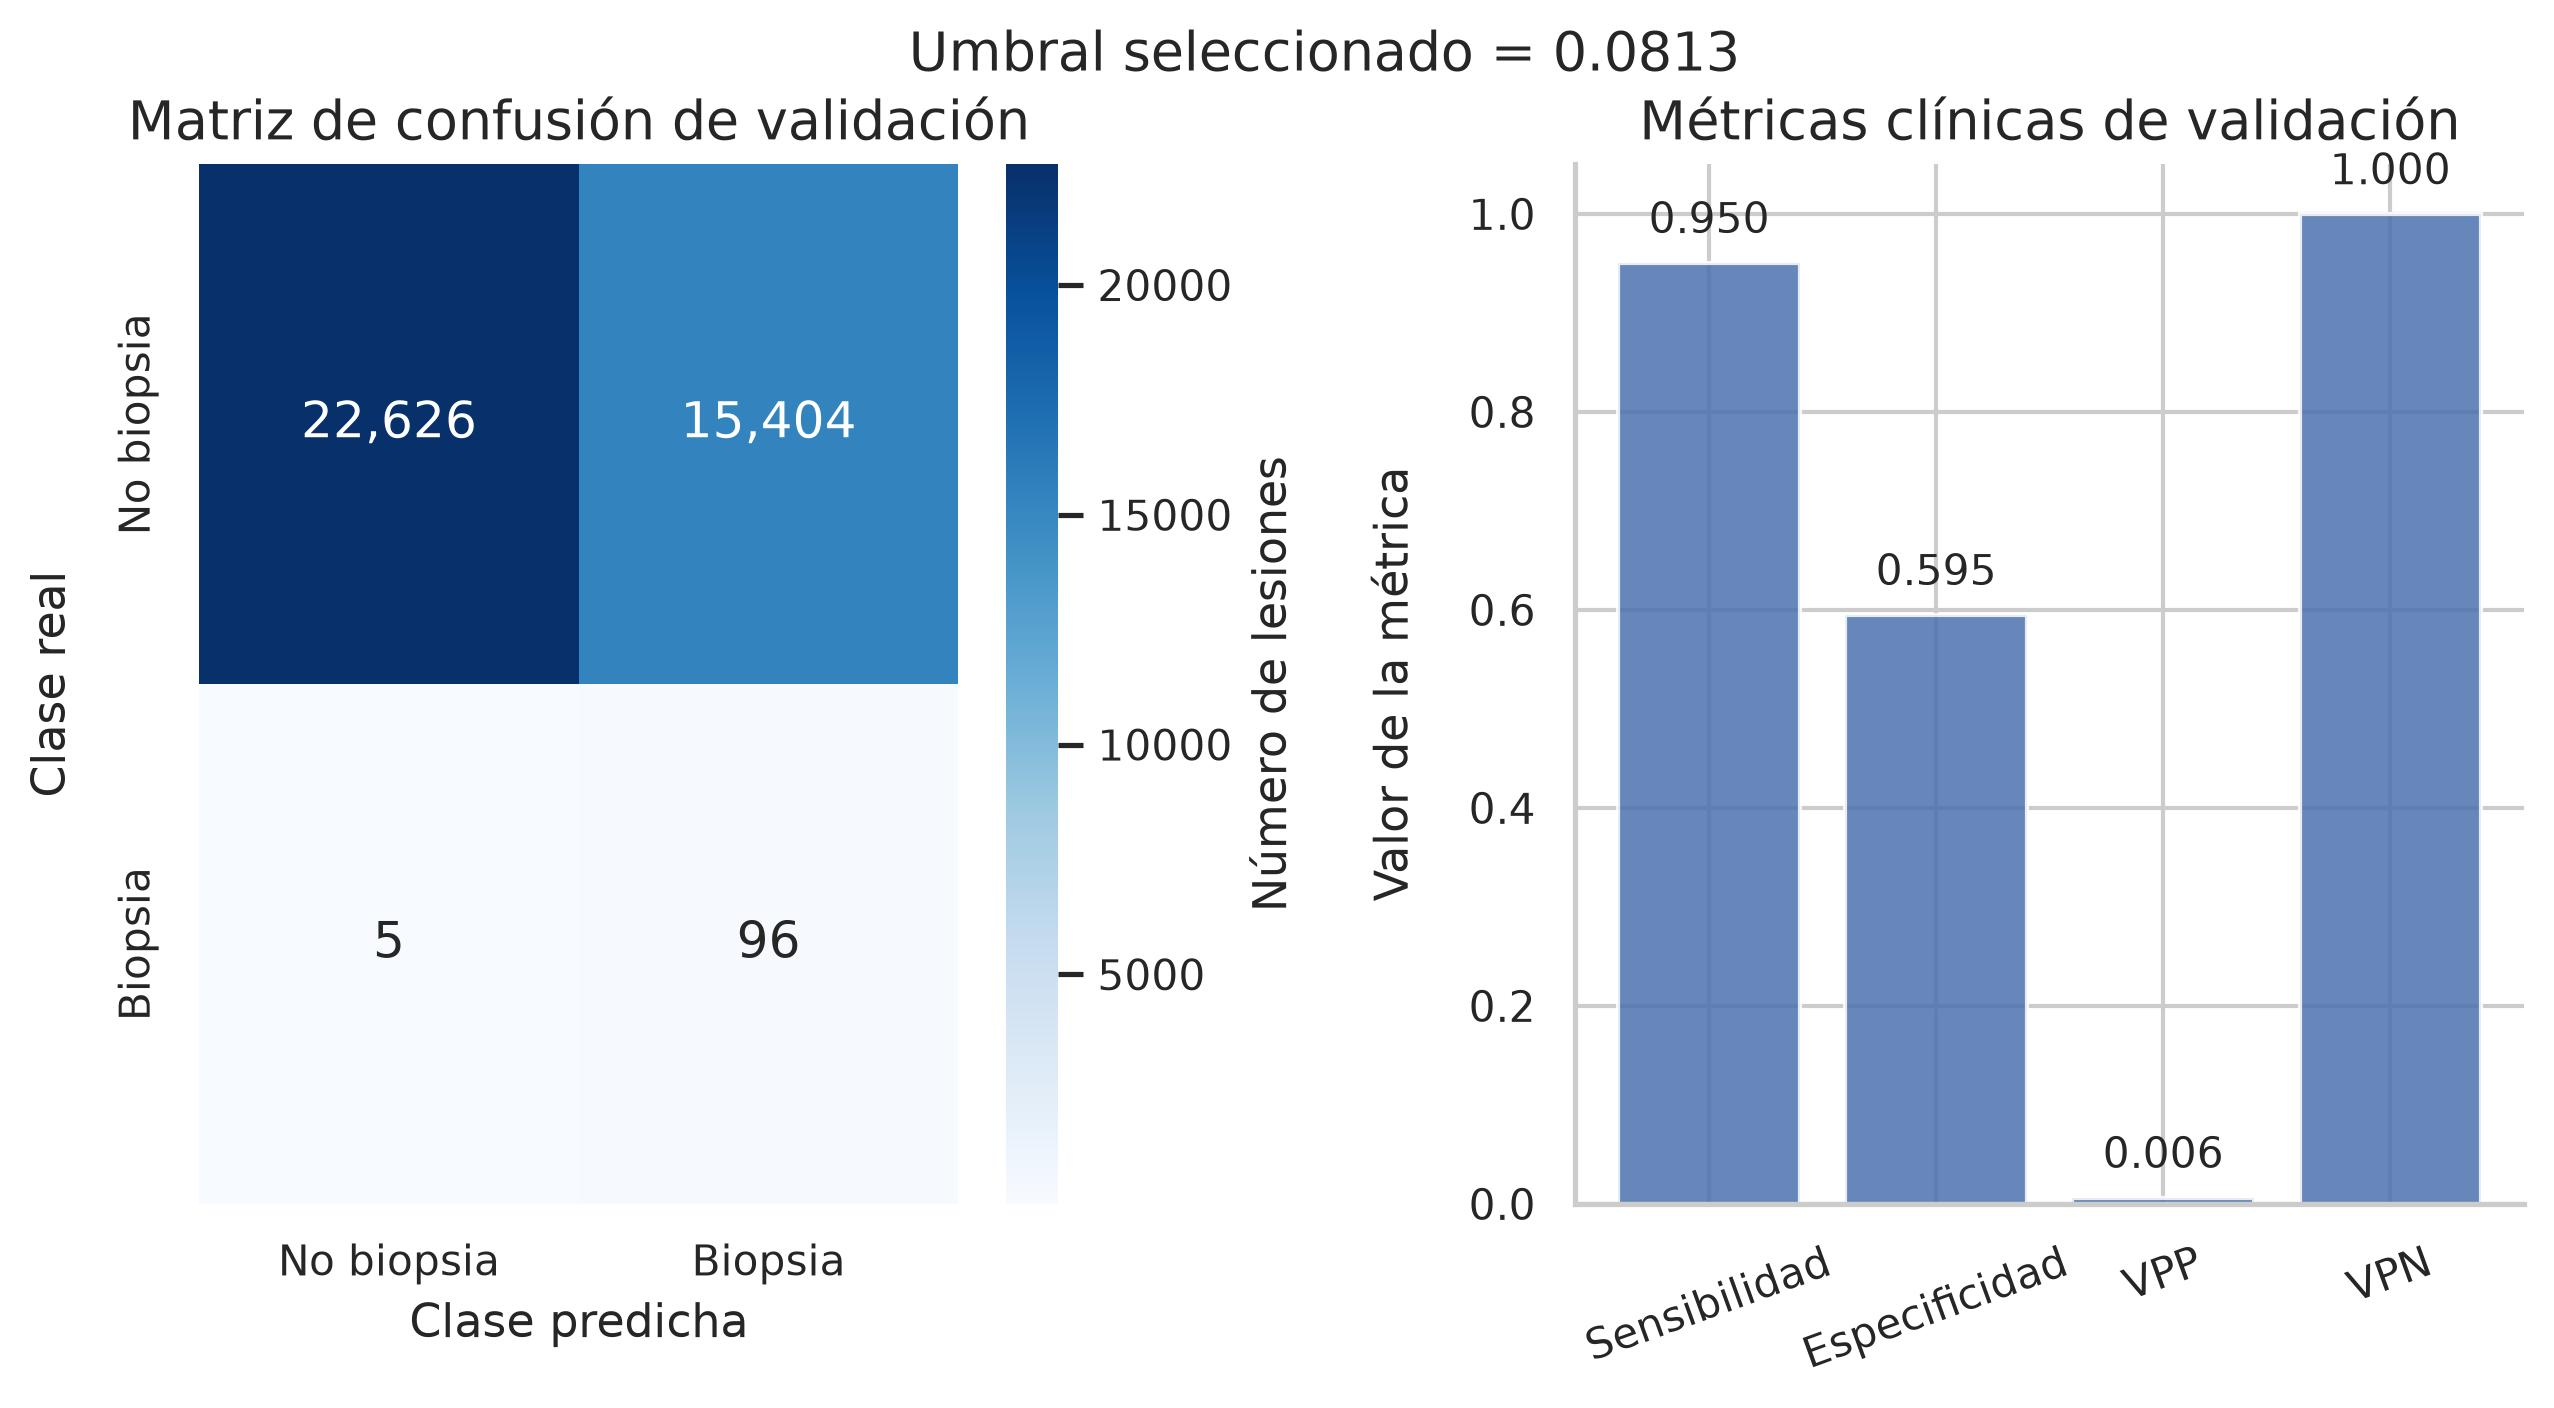

In [58]:
# ---------------------------------------------------------------------
# Display evaluation figures
# ---------------------------------------------------------------------

from IPython.display import (
    Image as IPythonImage,
    Markdown,
    display,
)

for figure_name, figure_path in results["figure_paths"].items():
    display(Markdown(f"### {figure_name.replace('_', ' ').title()}"))
    display(IPythonImage(filename=str(figure_path)))

# **CNN experiment summary**

The CNN experiment is complete through final external-validation evaluation.

The final model was obtained by refitting a fresh architecture on the complete selected training split using the training schedule determined exclusively during internal model development.

The experiment preserves:

* the official patient-level data partitions;
* the internal patient-grouped development holdout;
* the predefined PR-AUC → ROC-AUC → Brier model-selection hierarchy;
* the selected training schedule;
* training-specific class weighting;
* deterministic evaluation transforms;
* validation-only operating-point selection.

The evaluated CNN experiments use the **ImageNet transfer-learning protocol** described above.

The pipeline also exposes a reusable `scratch` initialization path, but from-scratch training is not part of the validated experimental protocol of this TFM. A dedicated scratch-specific optimization and validation strategy remains a possible future extension.

The official test partition remains untouched and is reserved for the
subsequent multimodal modelling stage.

## **Usage summary**

For comparable CNN experiments, normally change only the designated configuration cell.

The main experiment-level settings are:

* `HYPOTHESIS = 1` or `2`.
* `MODEL_ARCHITECTURE` to select the CNN architecture defined in `CNN_CONFIG`.
* `CNN_INITIALIZATION = "imagenet"` for the transfer-learning experiments evaluated in this TFM.
* `TRAIN_MAX_LESIONS = None` for the complete selected training split, or an integer for a reproducible patient-level reduced training run.
* `IMAGE_TIMESTAMP = None` to use the latest compatible 136×136 preprocessing run, or provide an exact timestamp when a specific preprocessing run must be reproduced.
* `BATCH_SIZE` according to available GPU memory.
* `WARMUP_EPOCHS`, `MAX_FINE_TUNE_EPOCHS`, `EARLY_STOPPING_PATIENCE` and `UNFREEZE_LAST_N_BLOCKS` when conducting a predefined transfer-learning configuration experiment.

The architecture-specific feature-stage configuration is defined centrally in `CNN_CONFIG` and should not be modified independently inside the training functions.

### **Recommended execution**

1. Use a small `TRAIN_MAX_LESIONS` value as a pipeline smoke test.
2. Confirm image loading, model construction, GPU training, internal validation, checkpoint selection, final refitting, saving and external-validation evaluation.
3. Return to `TRAIN_MAX_LESIONS = None` for the final H1/H2 experiment.

For comparable experiments, changes to the training configuration should be recorded in the experiment configuration saved with each model run.

### **Initialization strategies and future extensions**

The pipeline is designed so that the main data and modelling infrastructure can be reused with different CNN initialization strategies.

With `CNN_INITIALIZATION = "imagenet"`, the implemented training functions `train_with_internal_validation()` and `fit_final_model()` execute the validated **transfer-learning protocol** used in this TFM: classifier warm-up followed by architecture-specific partial fine-tuning.

With `CNN_INITIALIZATION = "scratch"`, the model is initialized without pretrained weights and the complete network remains trainable. The current functions provide the necessary implementation path to execute such a run, but the resulting two-stage optimization should be regarded as a **technical extension point rather than a validated scratch-training methodology**.

A dedicated from-scratch protocol could be added in future work, with its own training schedule, initialization and regularization strategy, learning-rate selection, training duration and model-selection procedure.

This separation allows the current notebook to remain reusable without conflating the transfer-learning methodology evaluated in the TFM with a different experimental regime that has not been empirically studied.

The official test images and labels remain reserved for the subsequent multimodal modelling stage and are not used for CNN model-development or operating-point selection.